In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from particlefield import wrap_centered, unwrap_periodic, get_params_from_scales
import pandas as pd

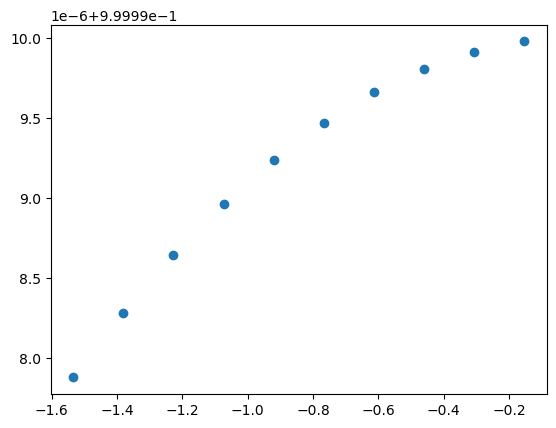

In [27]:
field_length_scale=0.03
field_time_scale=0.1
particle_time_scale=1e-3
mu=1
kappa=50.0
params = get_params_from_scales(field_length_scale=field_length_scale,
                       field_time_scale=field_time_scale,
                       particle_time_scale=particle_time_scale,
                       mu=mu,
                       kappa=kappa)
gamma= params["gamma"]
K = params["K"]
gamma_tilde = params["gamma_tilde"]
dt = 1e-4
dx = 0.01
N = 4096
L = N*dx
import numpy.fft as fft
q = 2*np.pi*fft.fftfreq(N, d=dx)
q2 = q**2
plt.scatter(q[-10:],(np.exp(-(mu + K*q2)*(dt*q2) / gamma_tilde))[-10:])

In [3]:
data_files = list(Path("data").glob("*.npz"))

In [4]:
df = []
for data_file in data_files:
    data = np.load(data_file, allow_pickle=True)
    params = data["params"].item()
    v = params["v"]
    dt = params["dt"]
    L = params["L"]
    #phi_qs = data["phi_qs"]
    z_hist = data["z_hist"]
    #z_hist = z_hist[:len(z_hist)//3]
    z_unwrapped = unwrap_periodic(z_hist, L)
    u_unwrapped = v*dt*np.arange(len(z_unwrapped)) - z_unwrapped
    u_centered = wrap_centered(v*dt*np.arange(len(z_unwrapped)) % L - z_hist, L)
    u_centered_unwrapped = unwrap_periodic(u_centered, L)
    df.append(params | {"unwrapped_u_series": u_unwrapped, "centered_u_series": u_centered, "centered_u_unwrapped_series": u_centered_unwrapped})
df = pd.DataFrame(df)

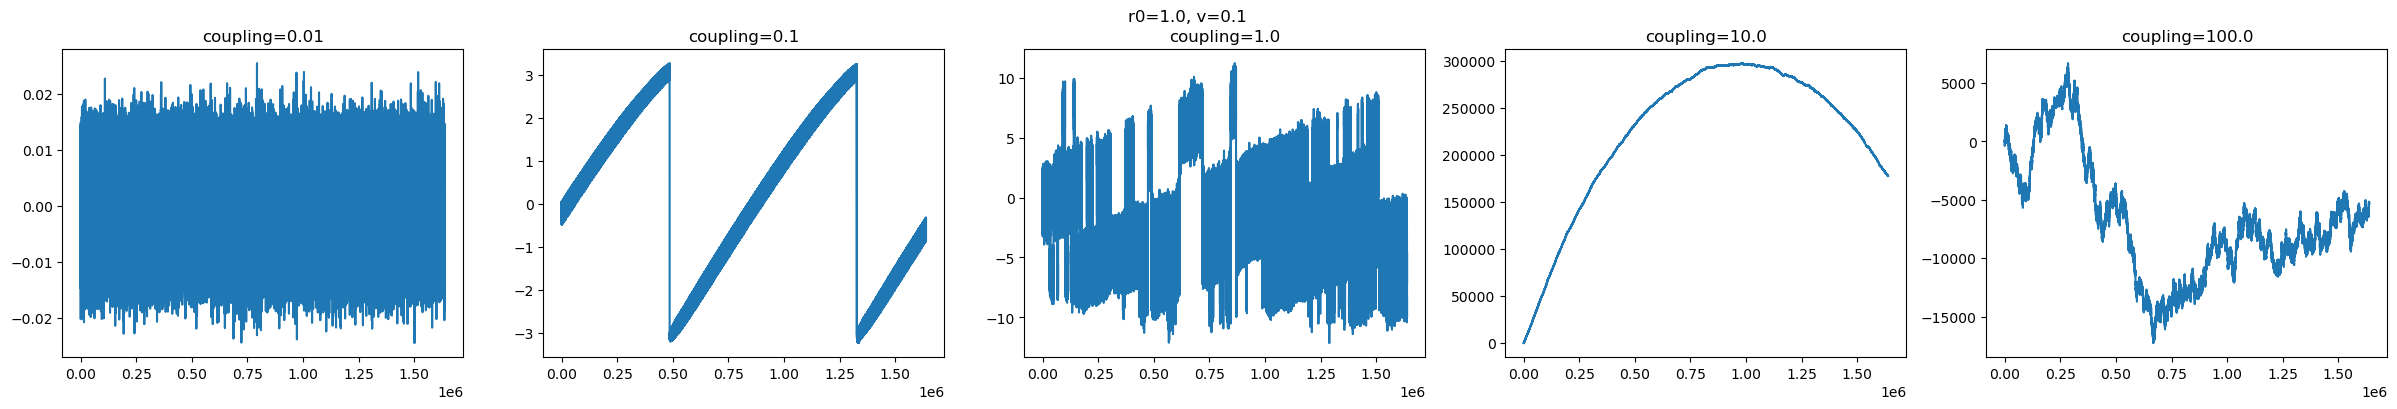

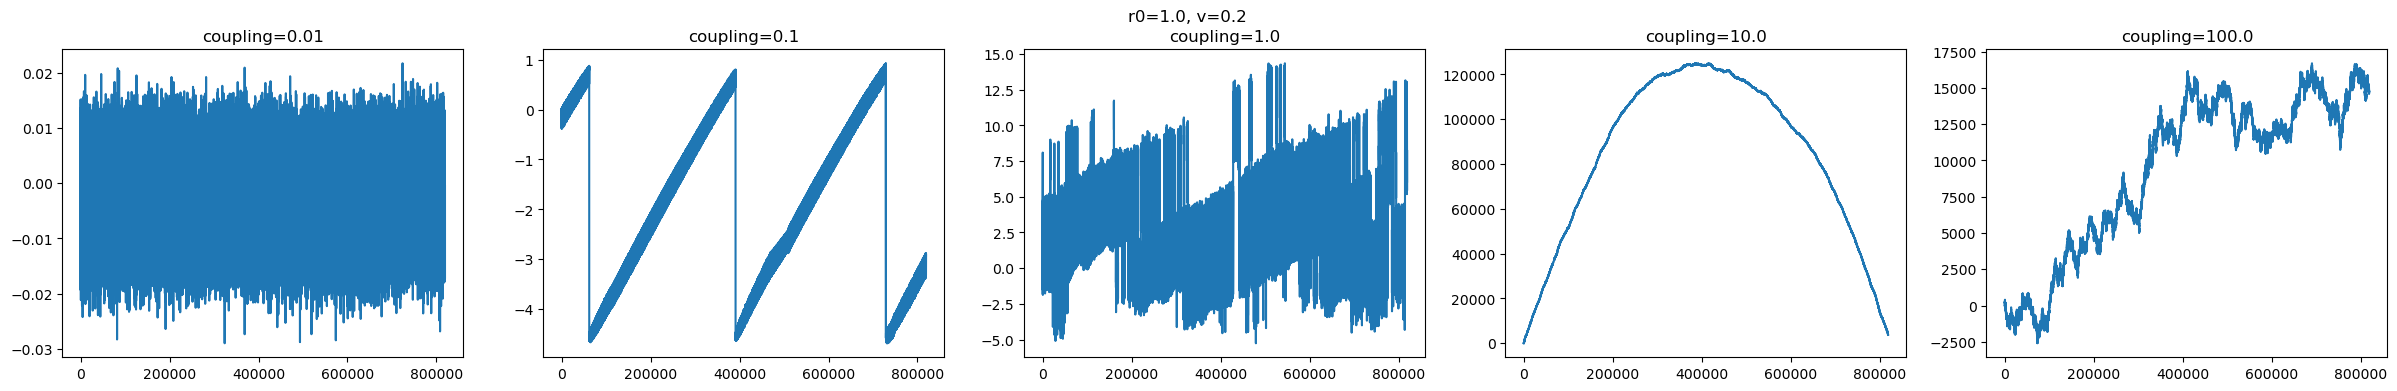

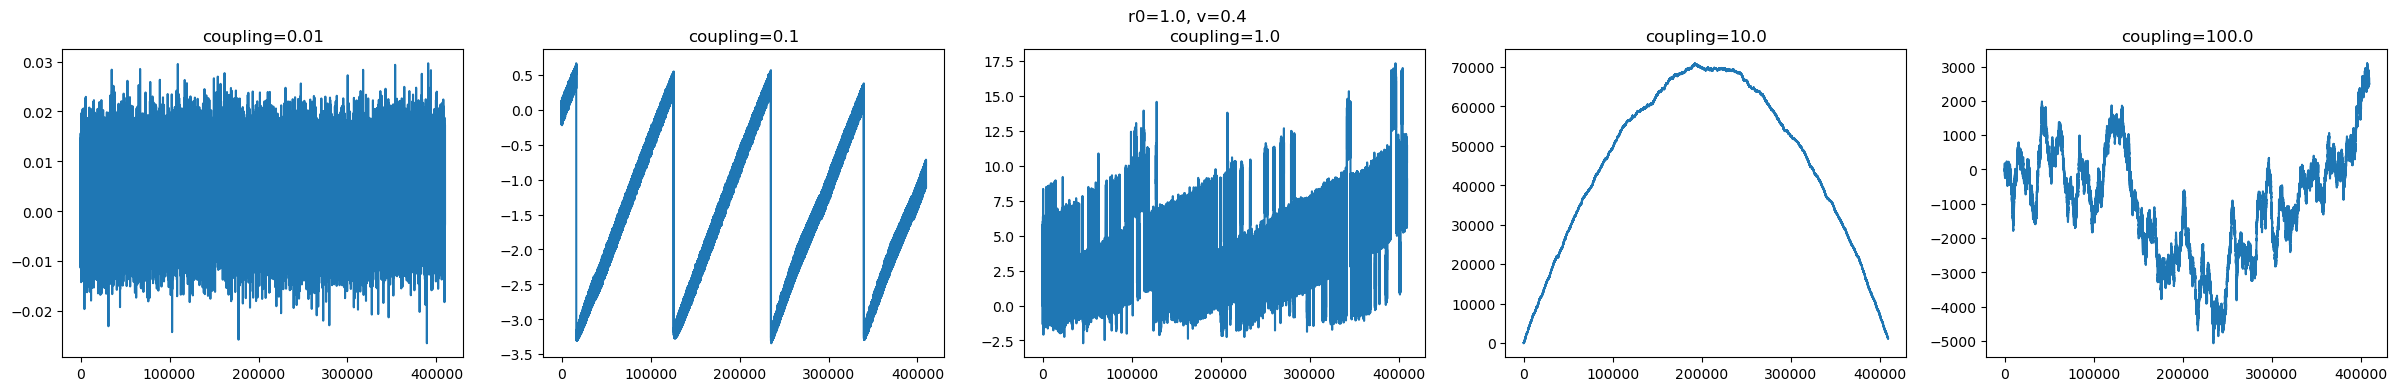

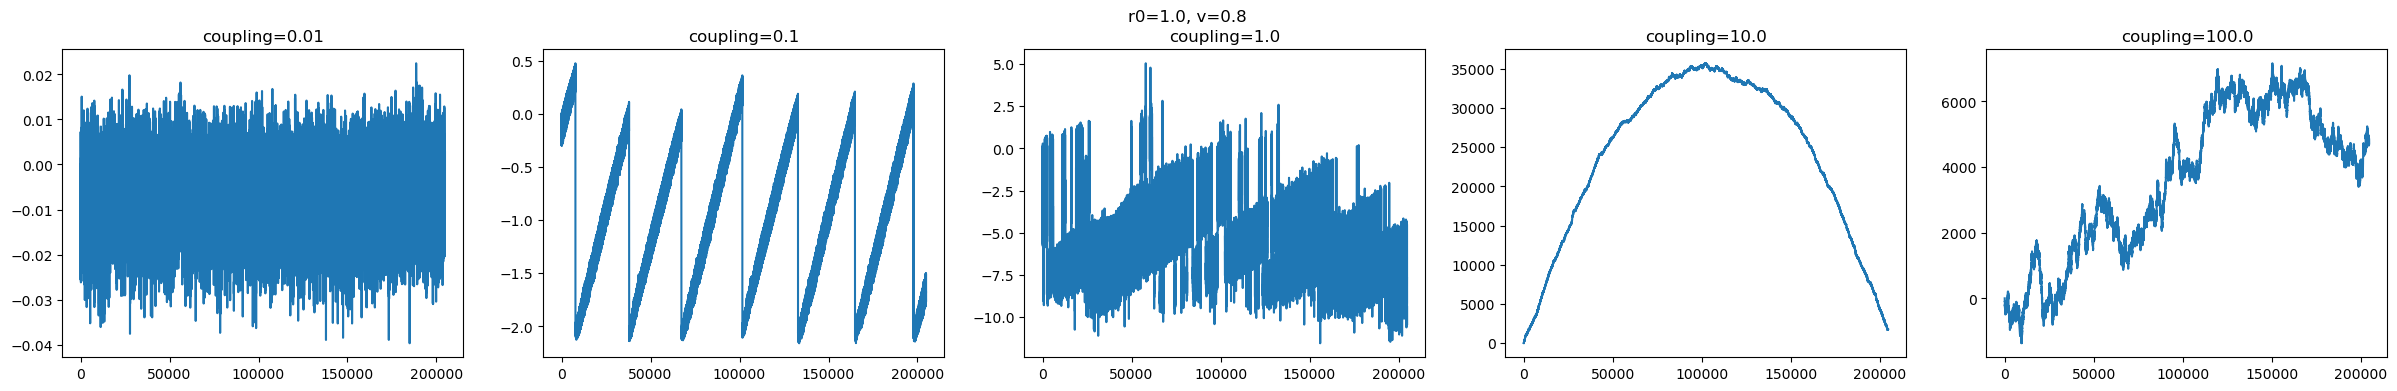

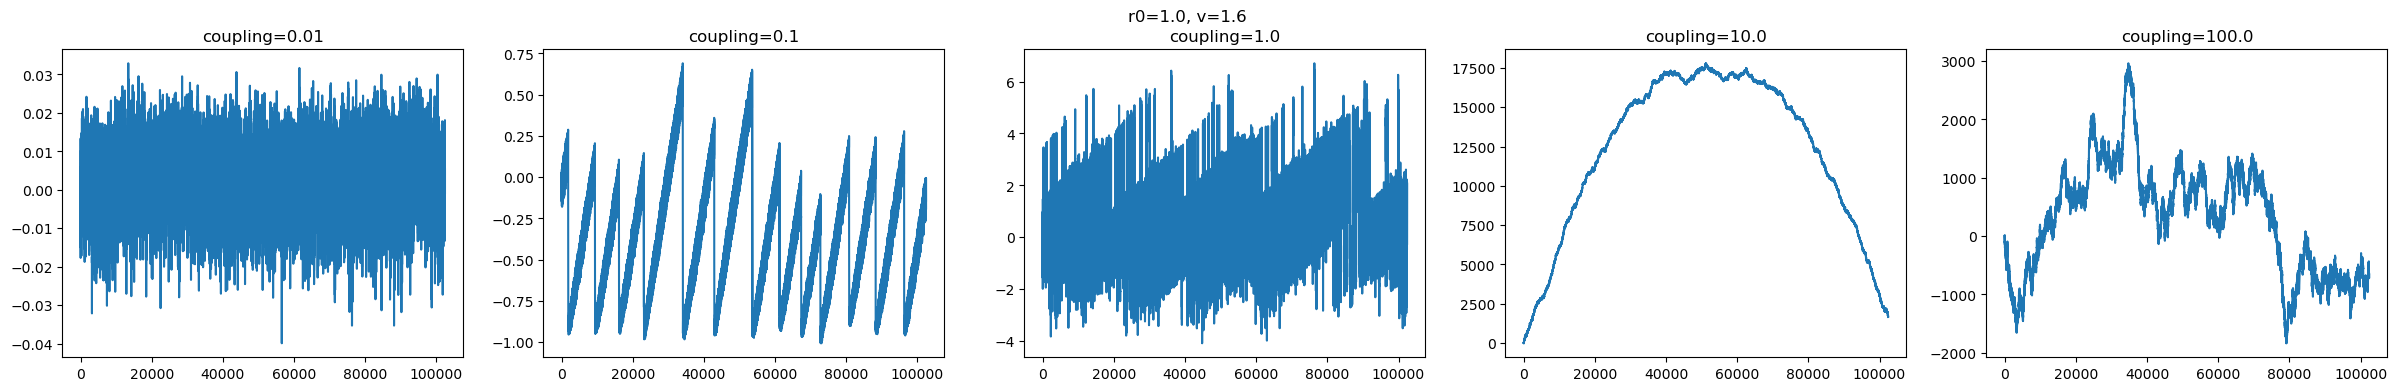

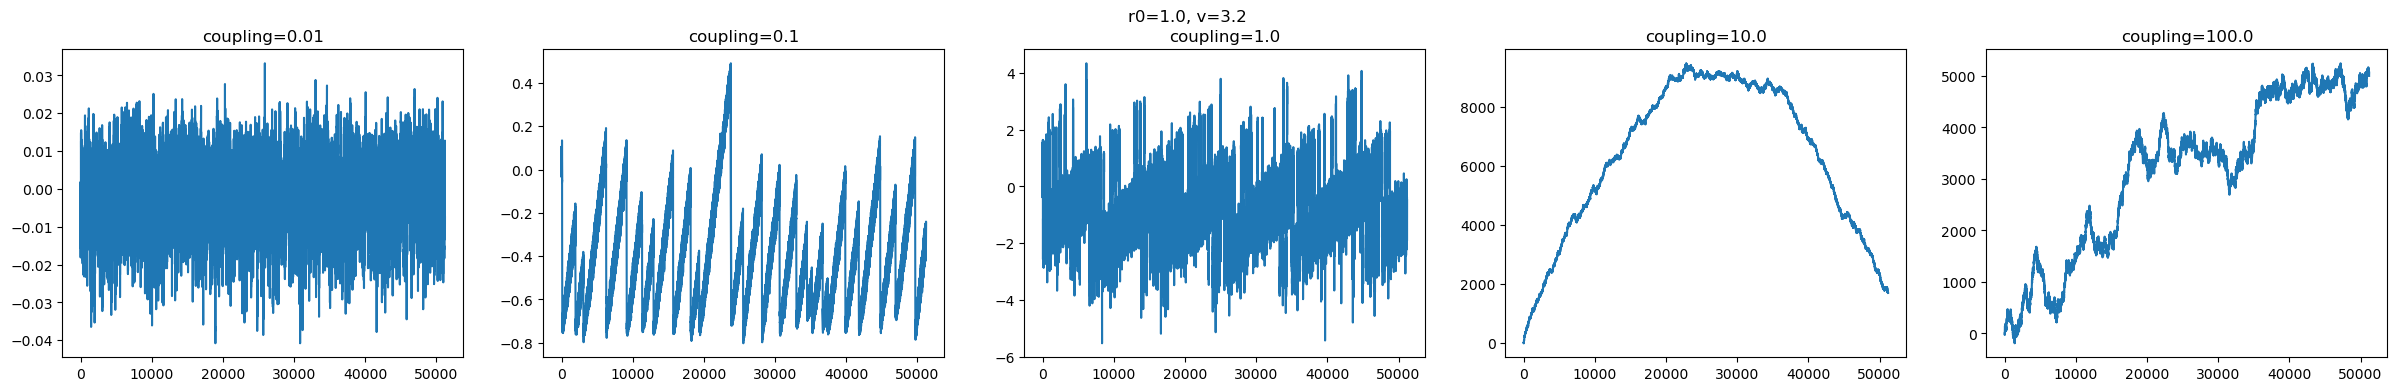

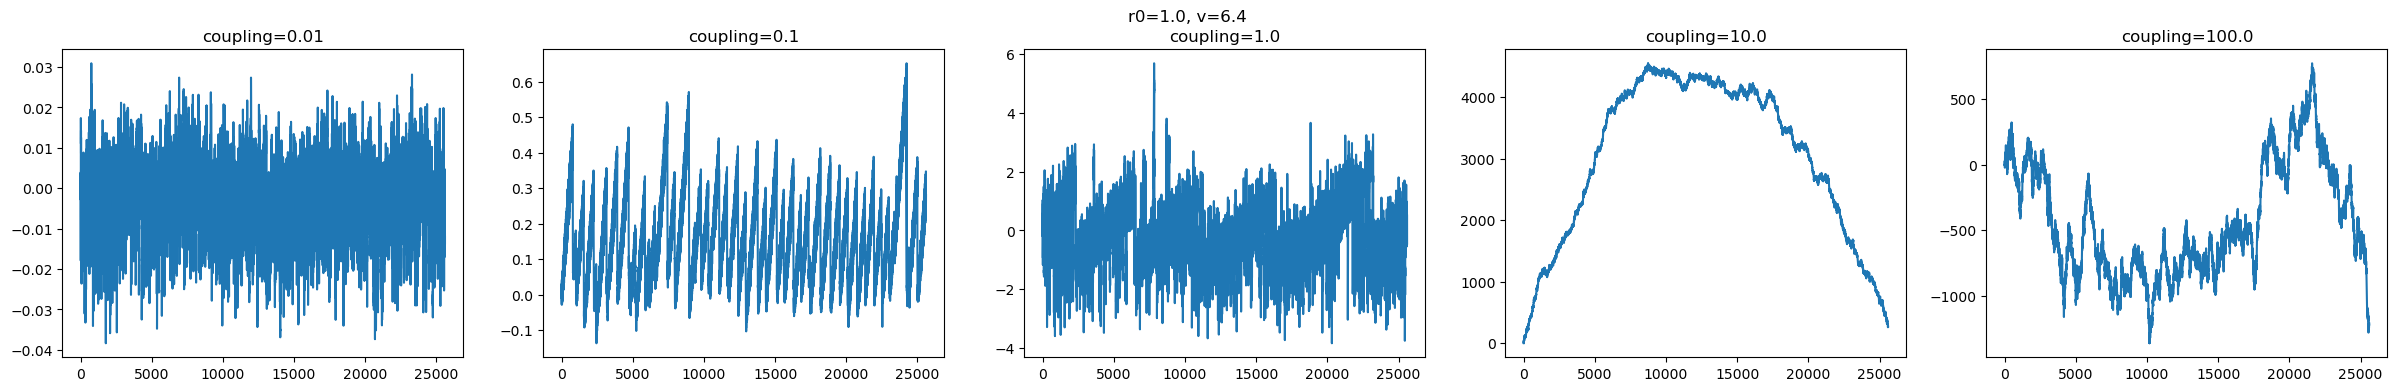

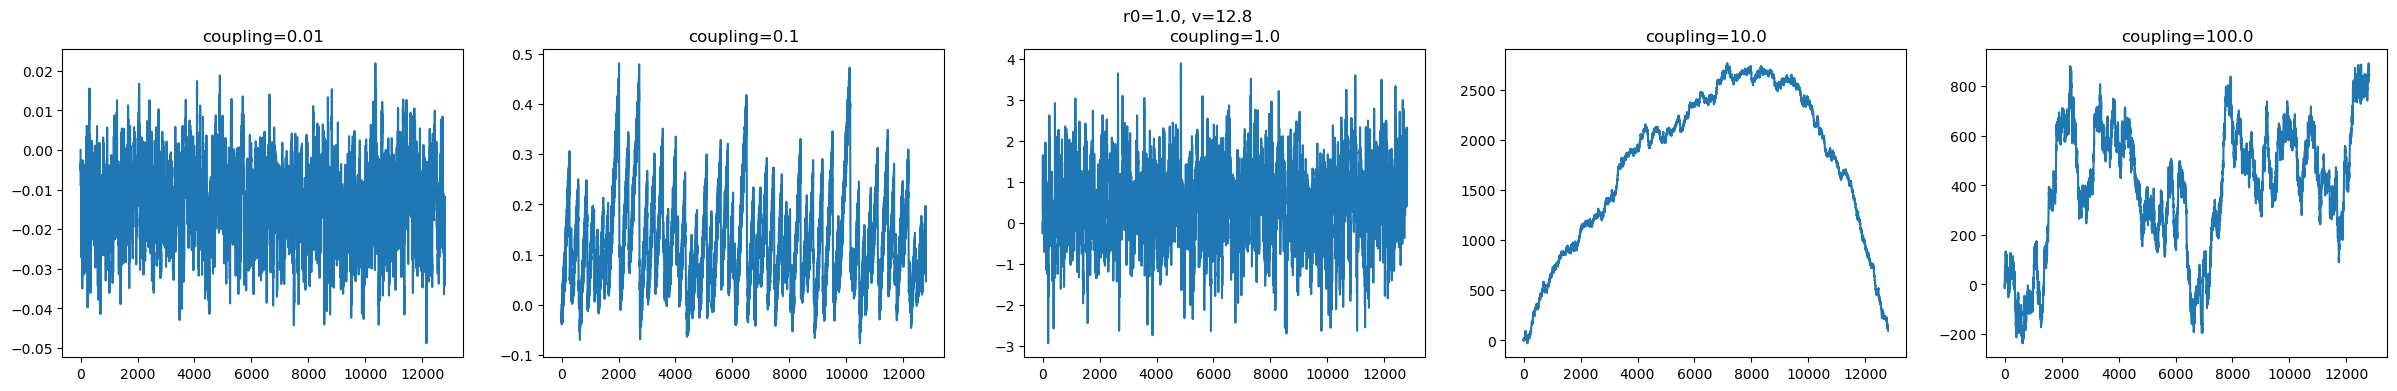

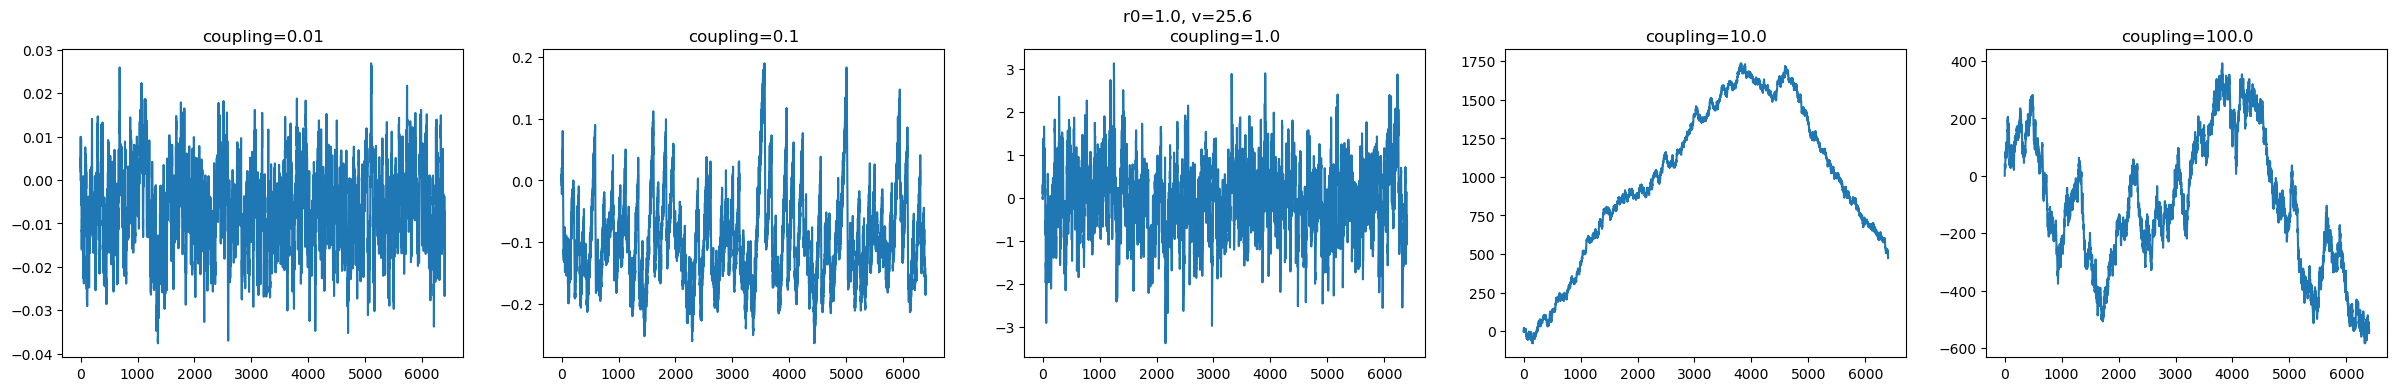

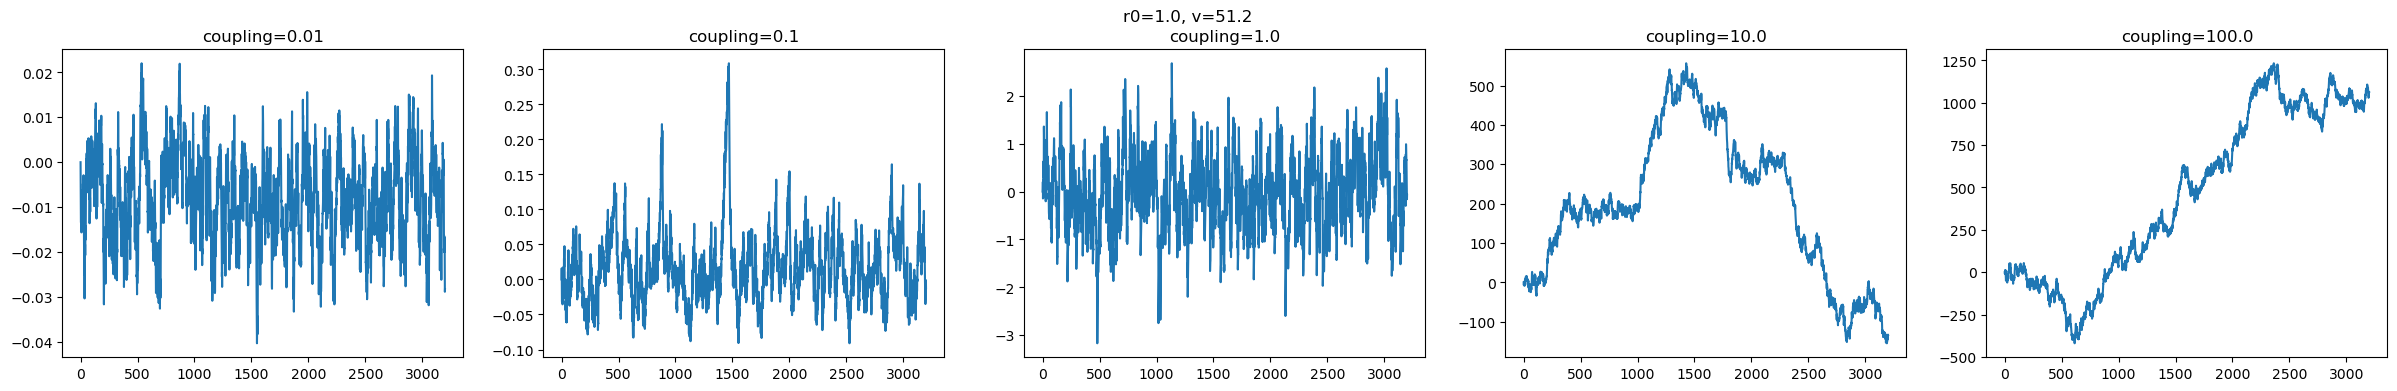

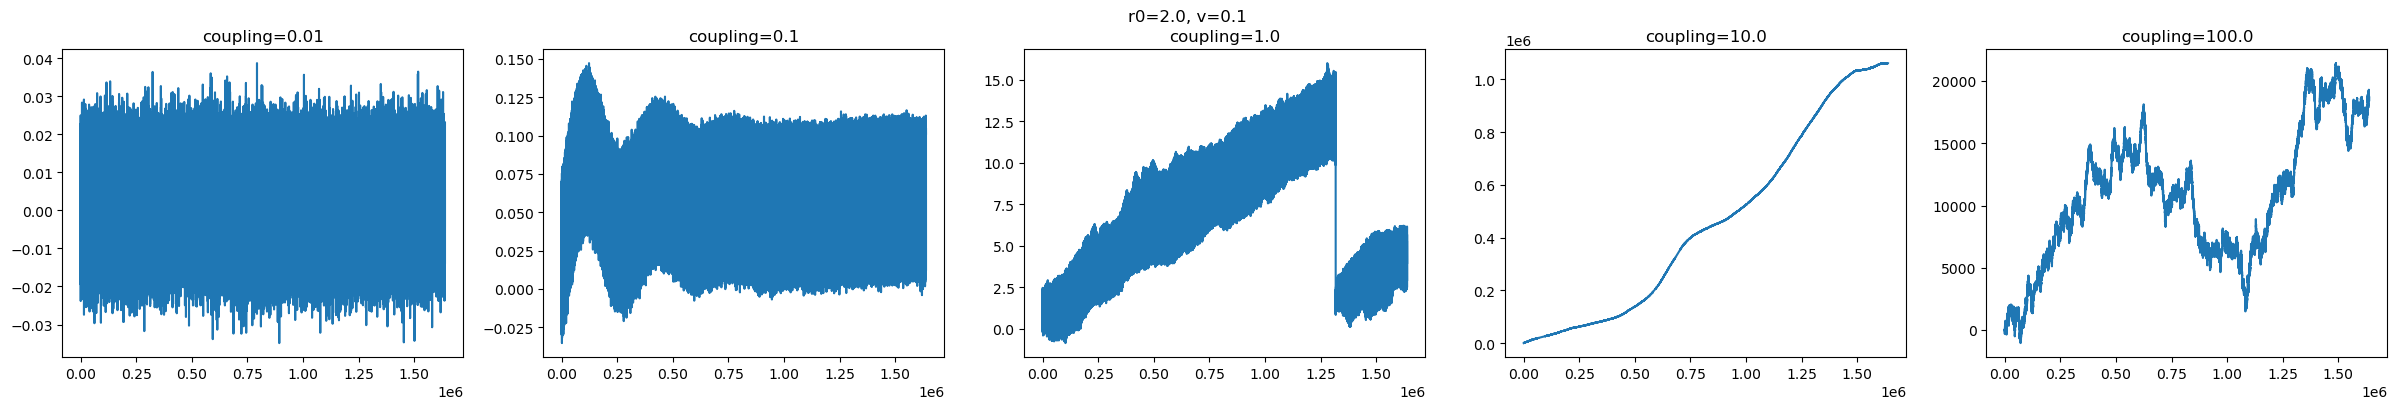

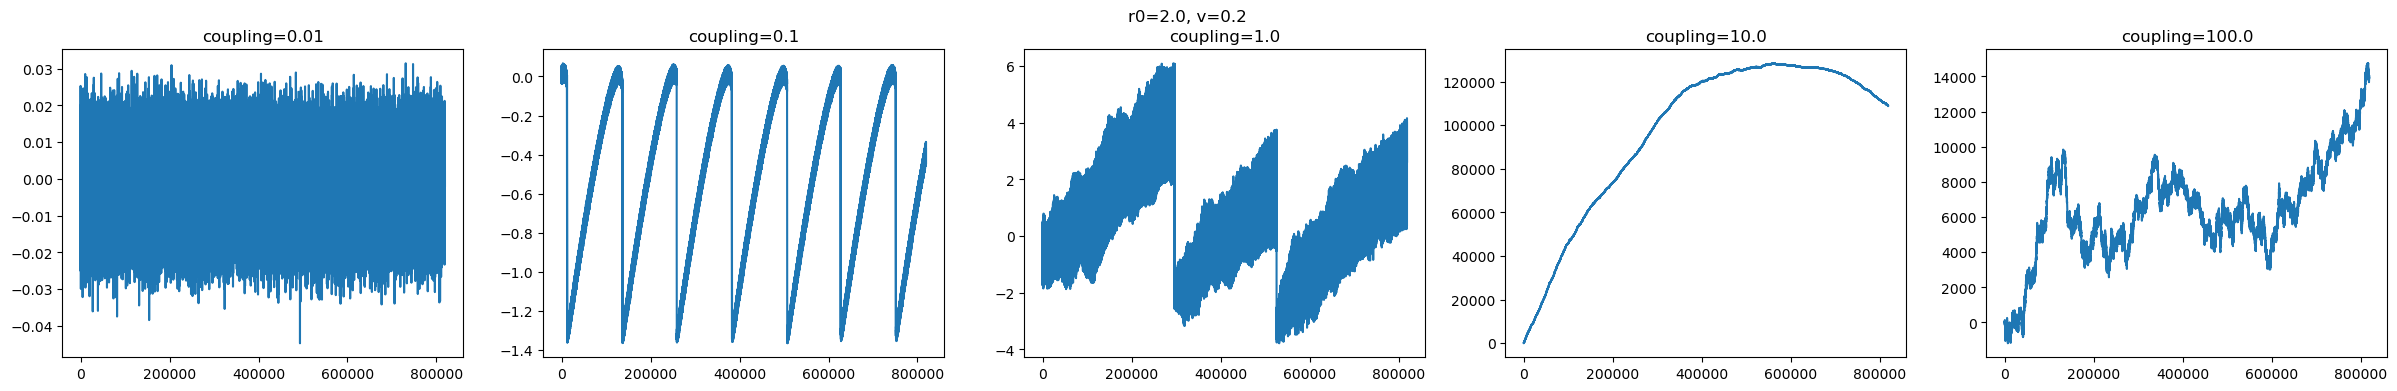

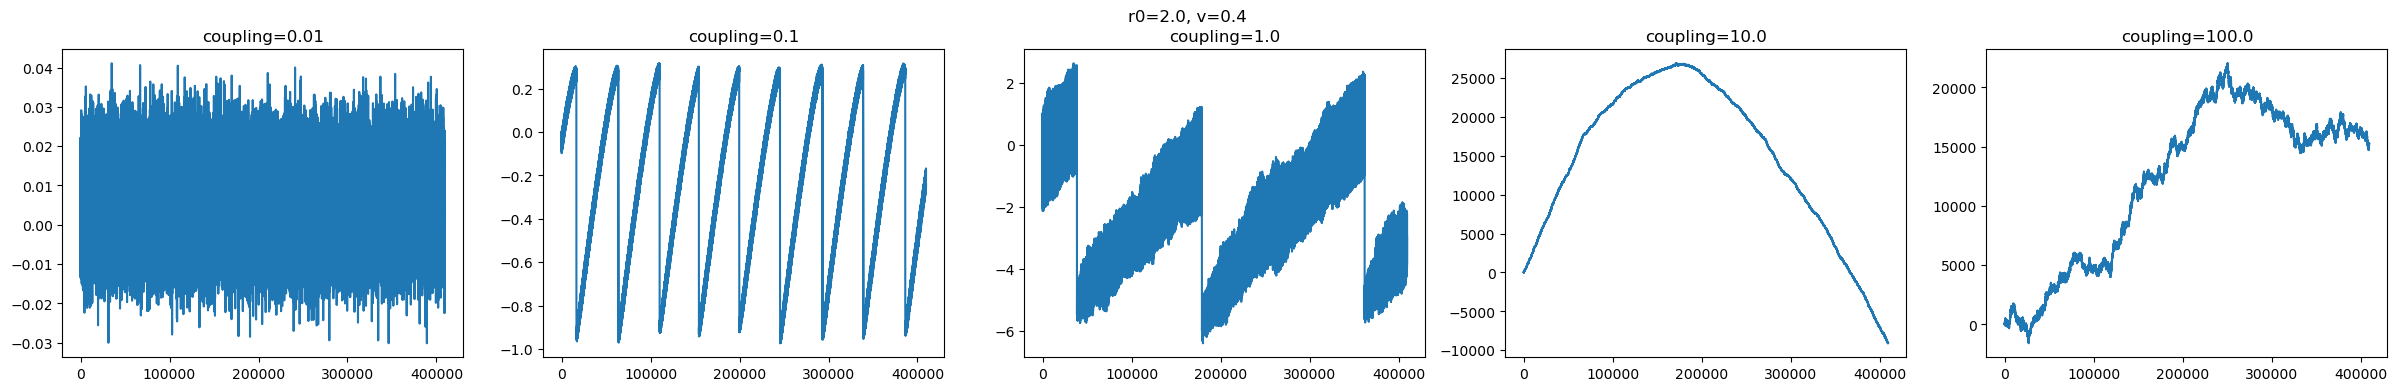

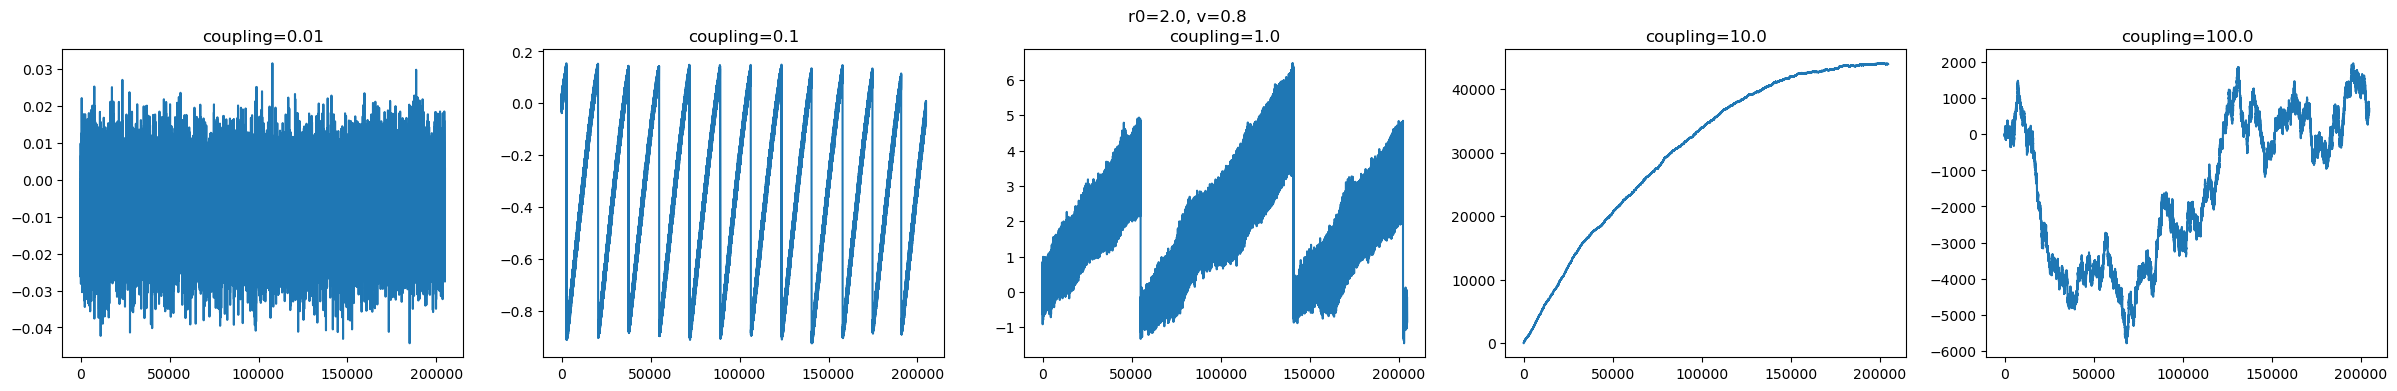

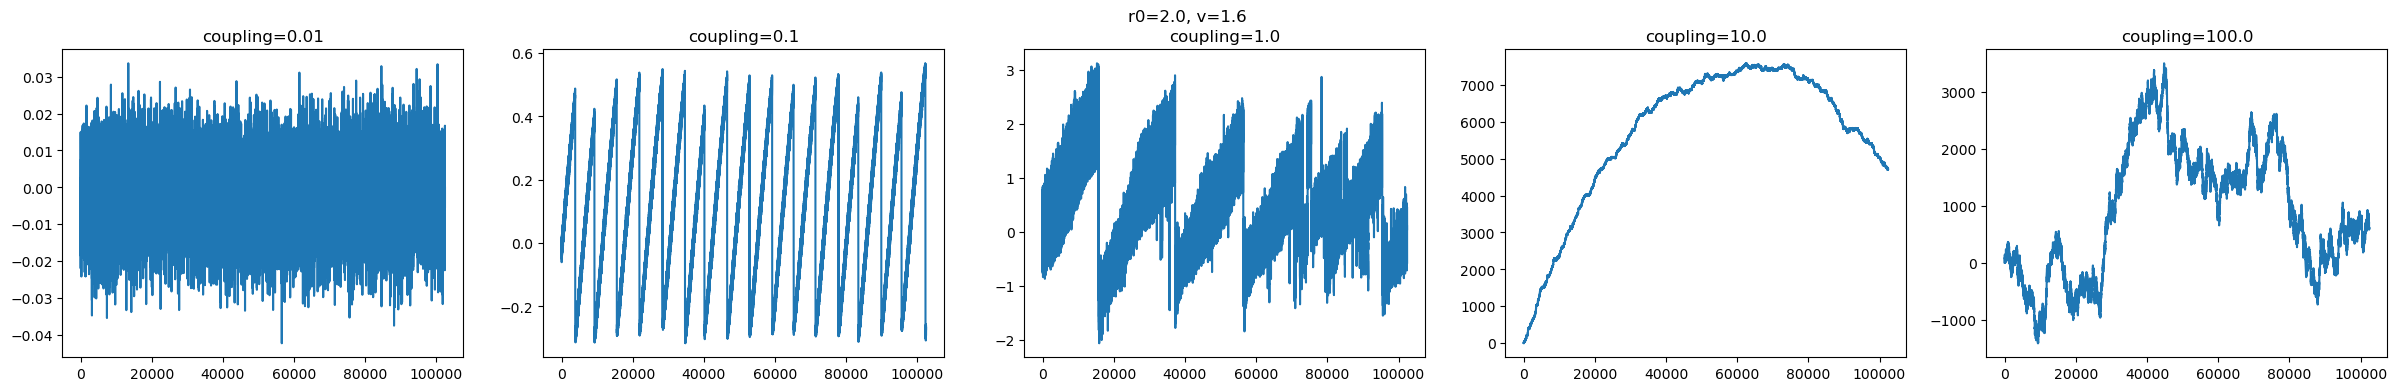

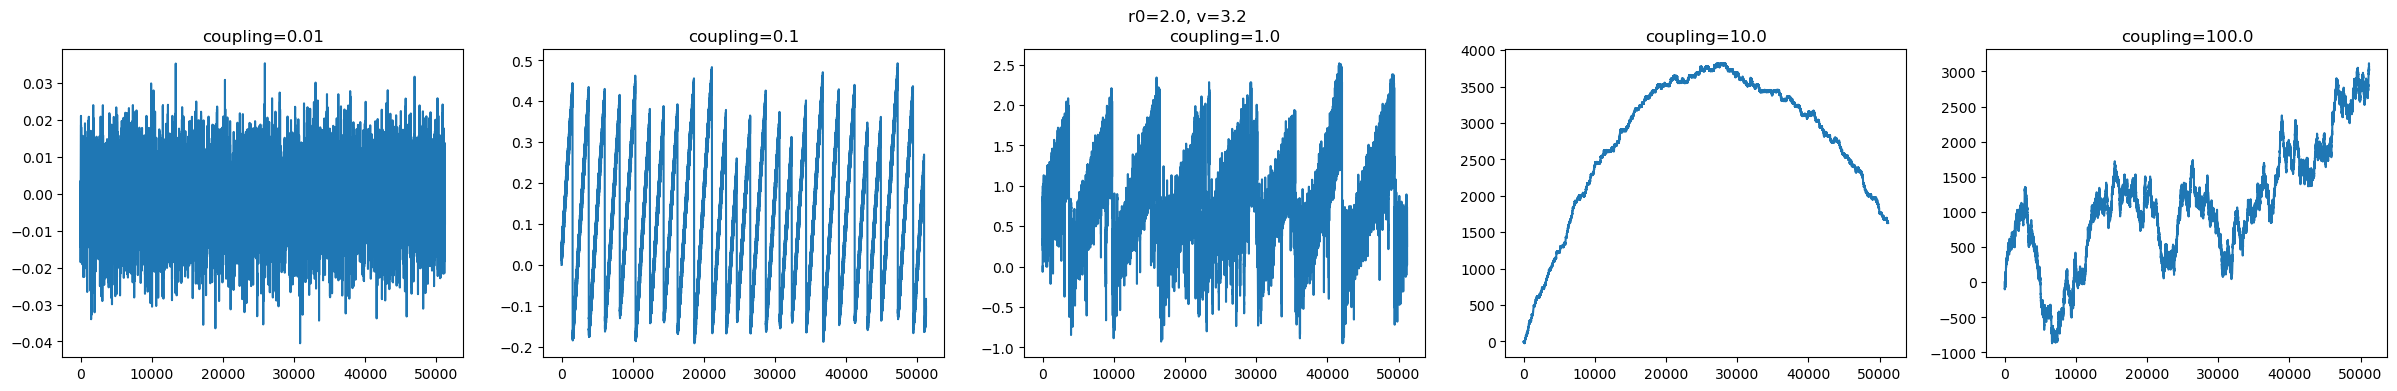

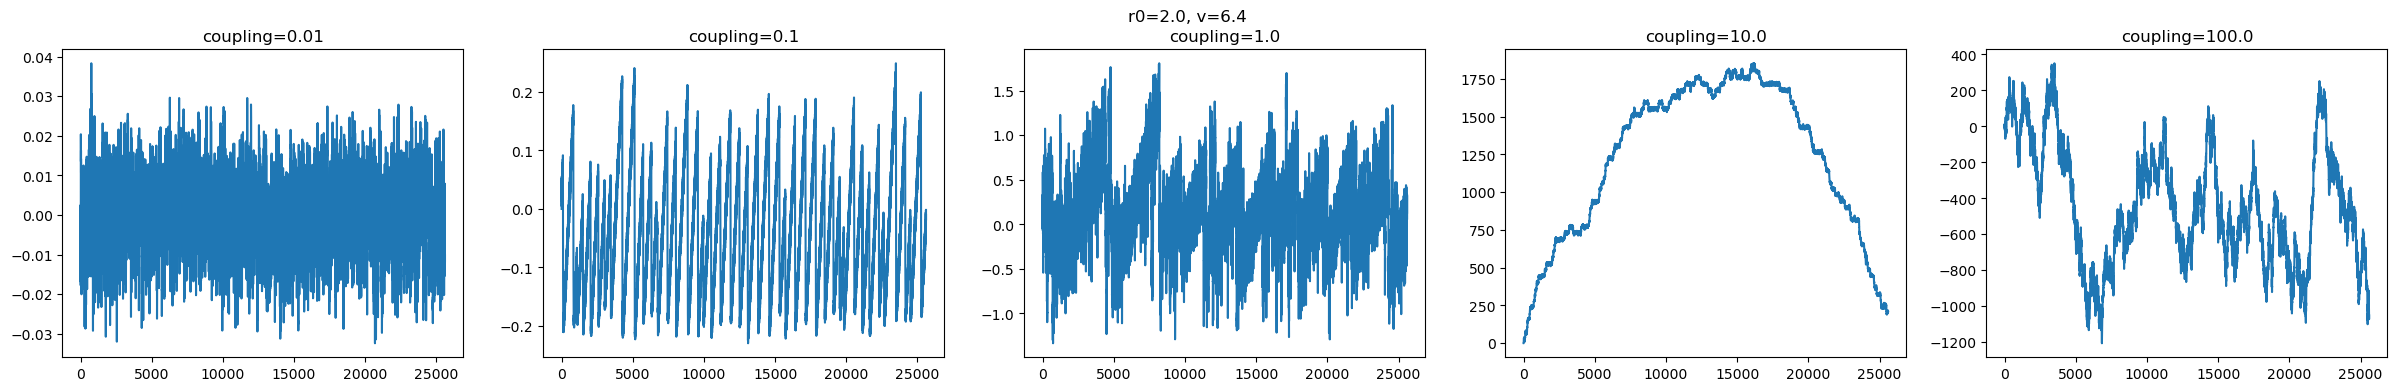

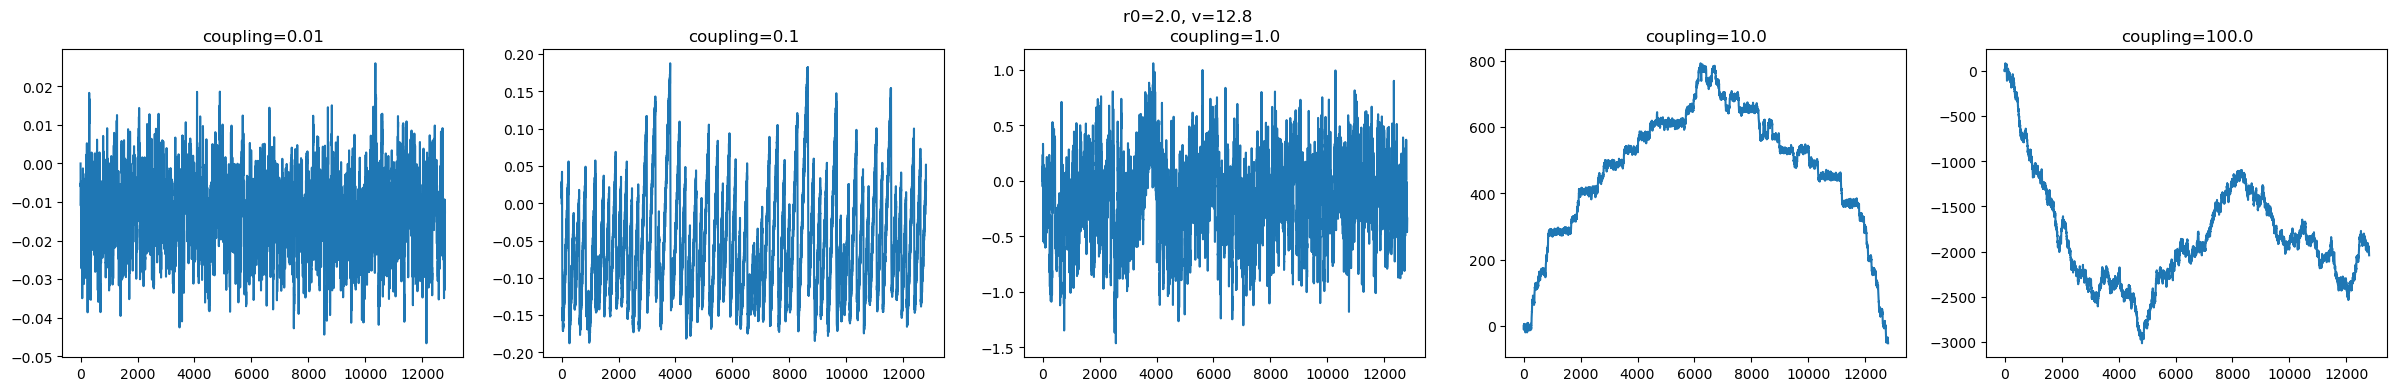

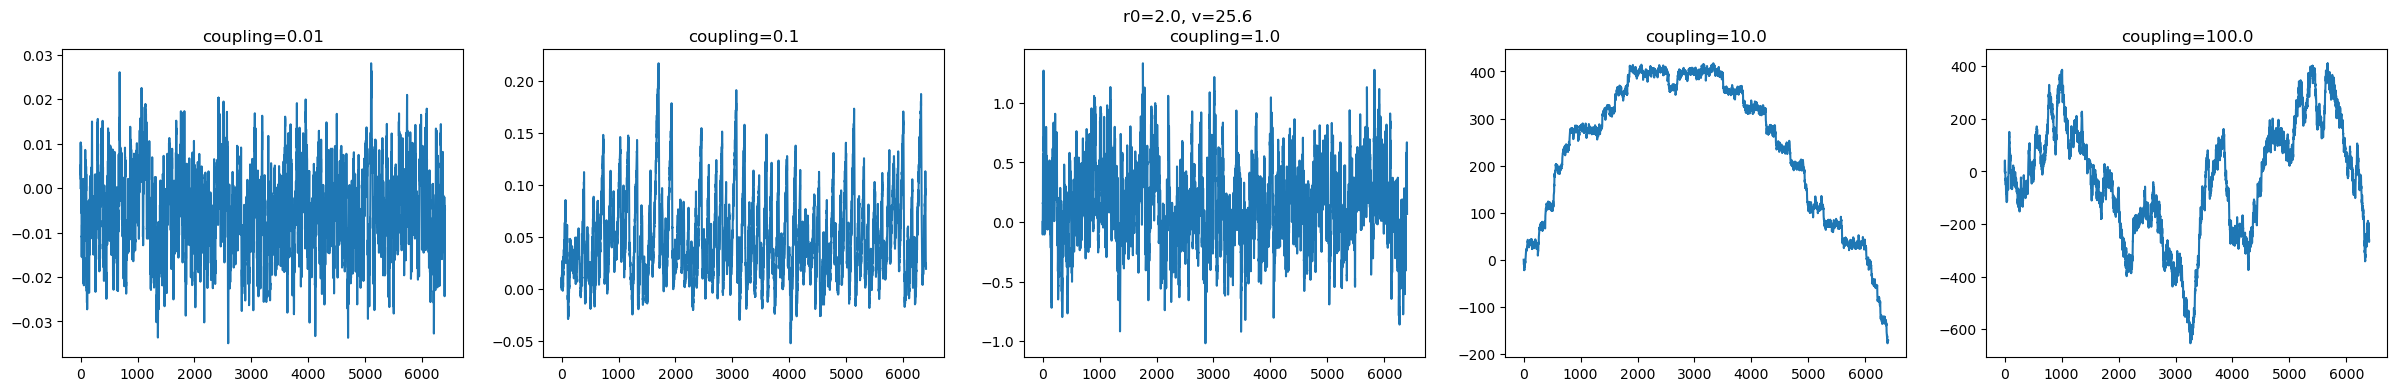

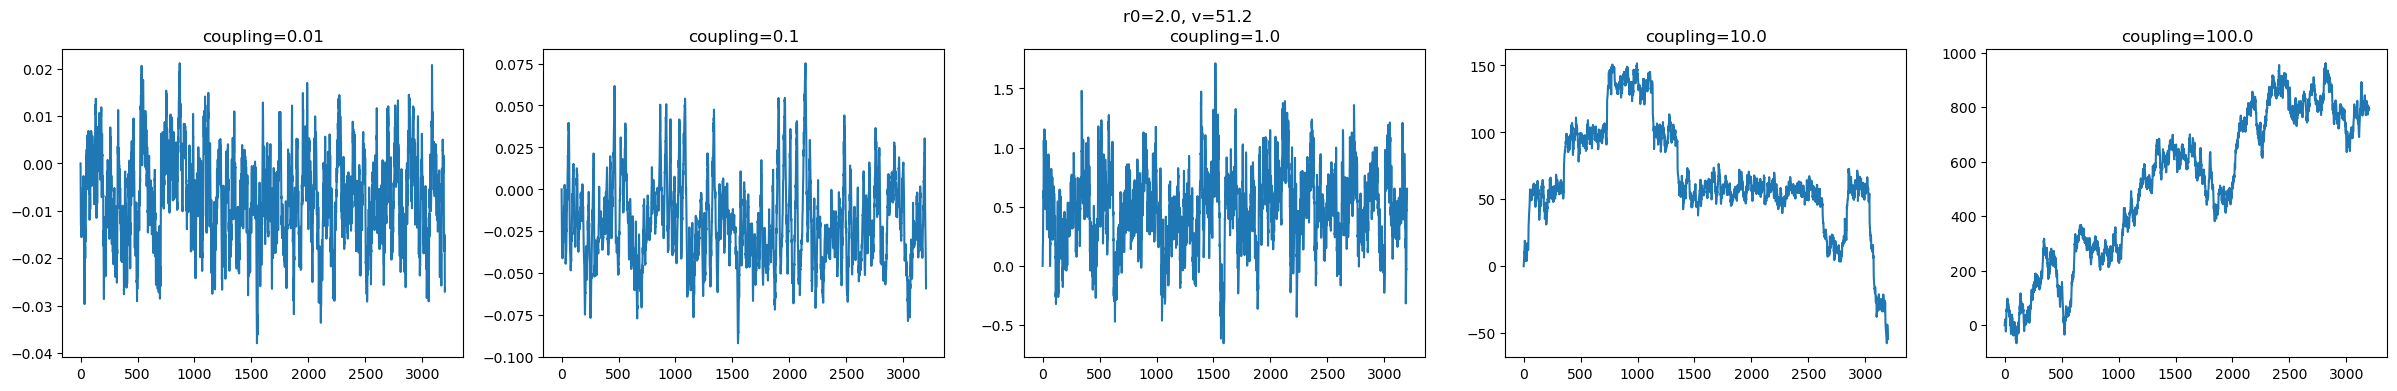

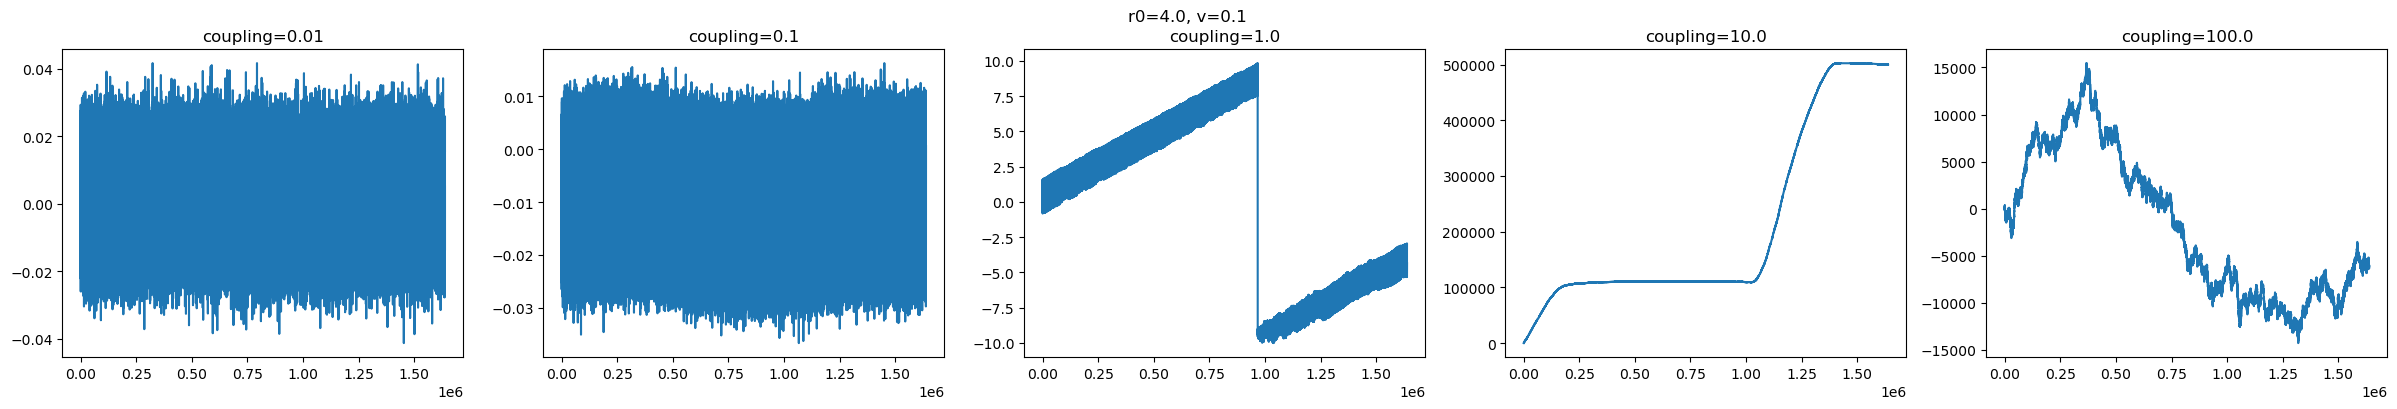

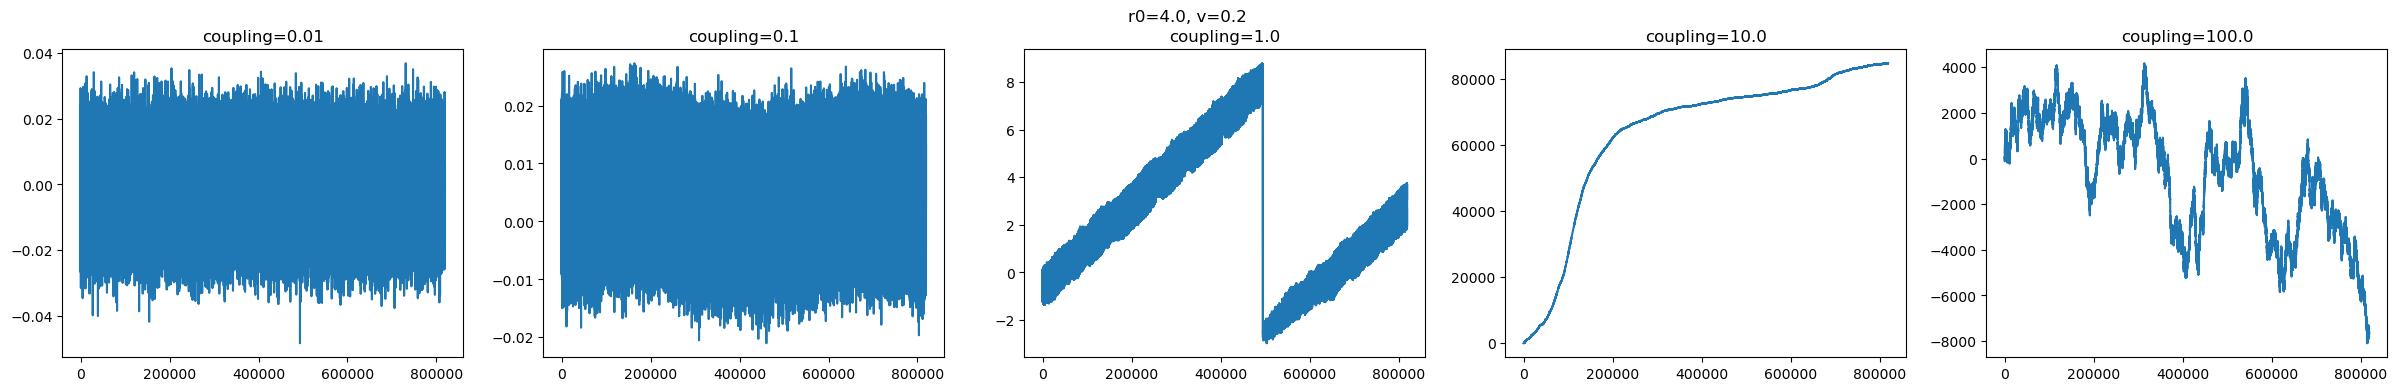

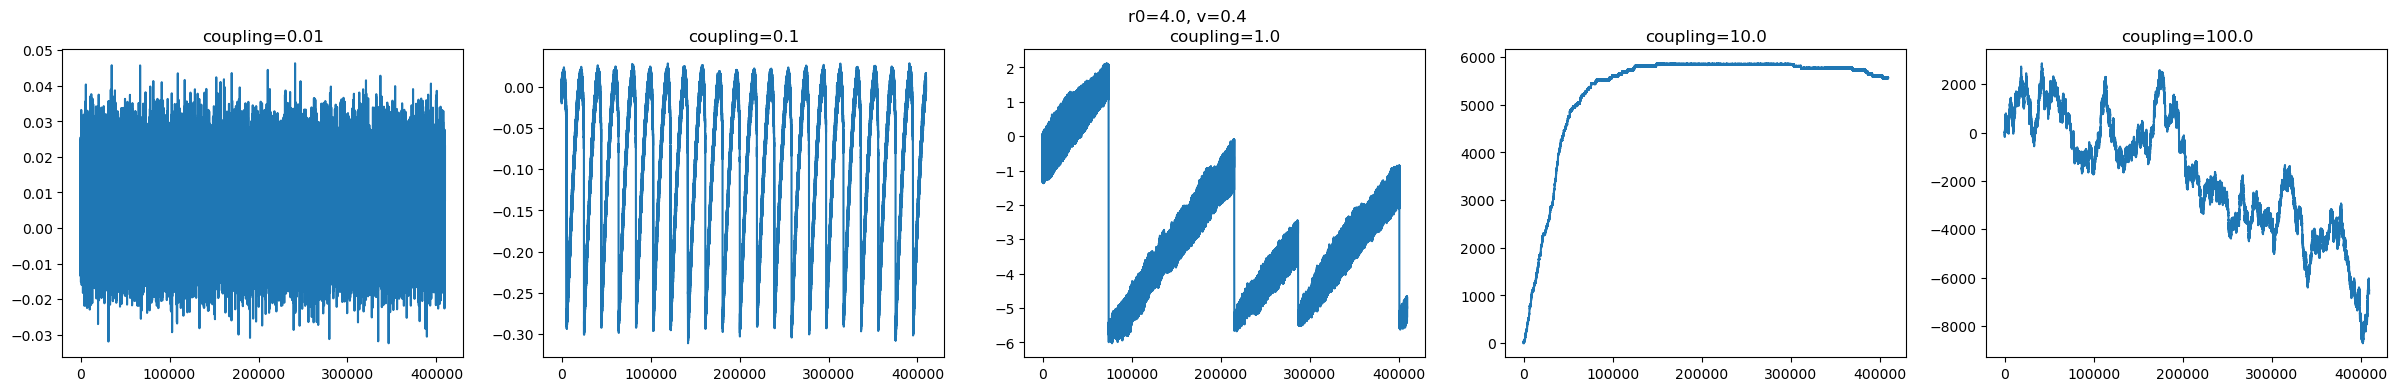

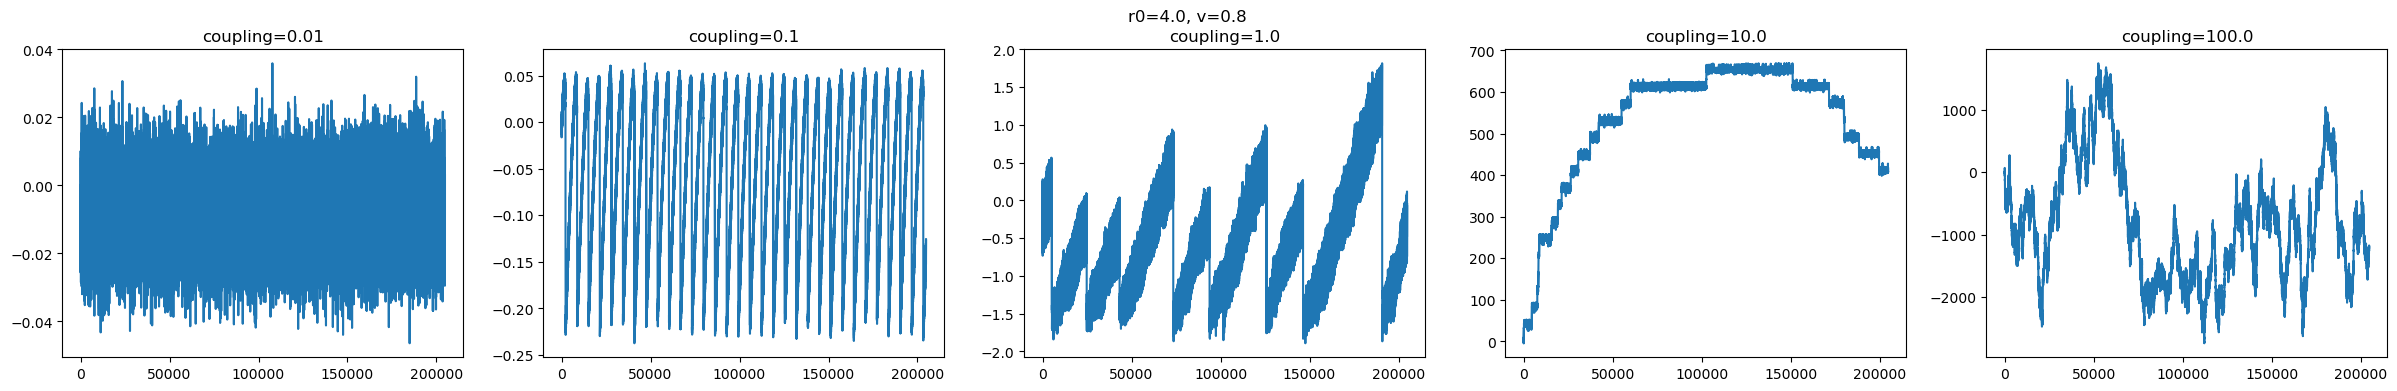

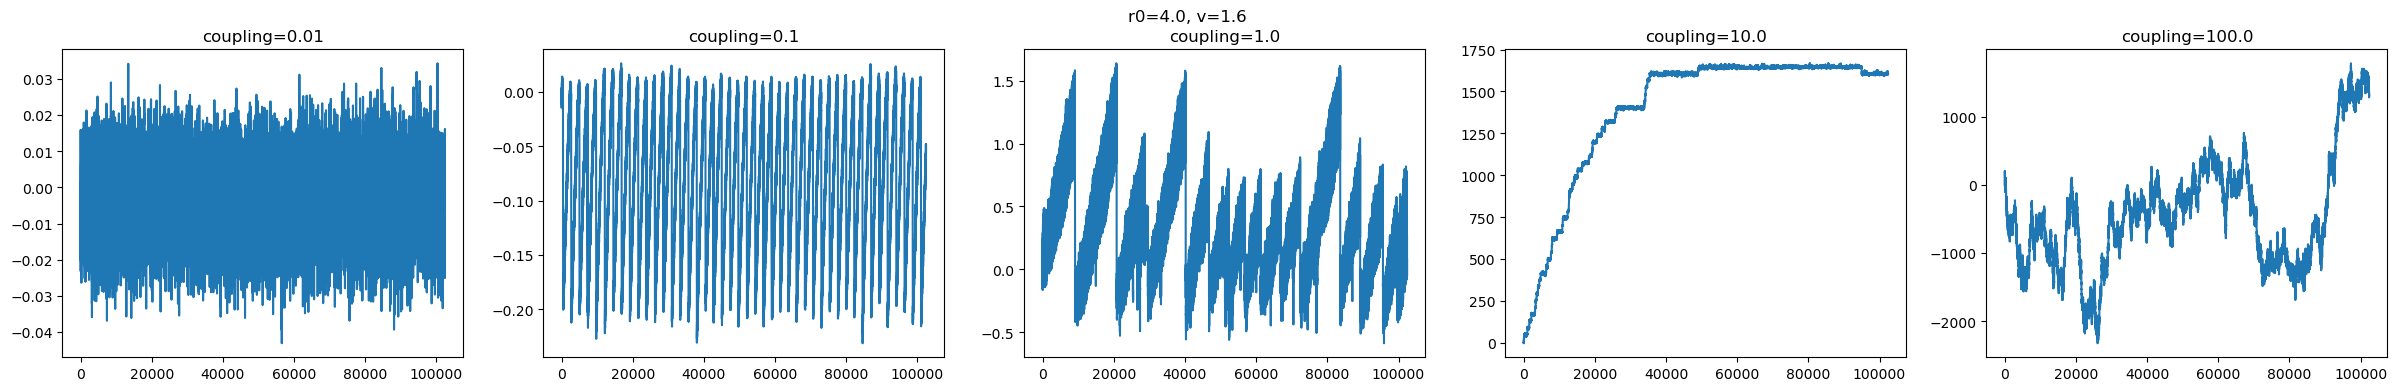

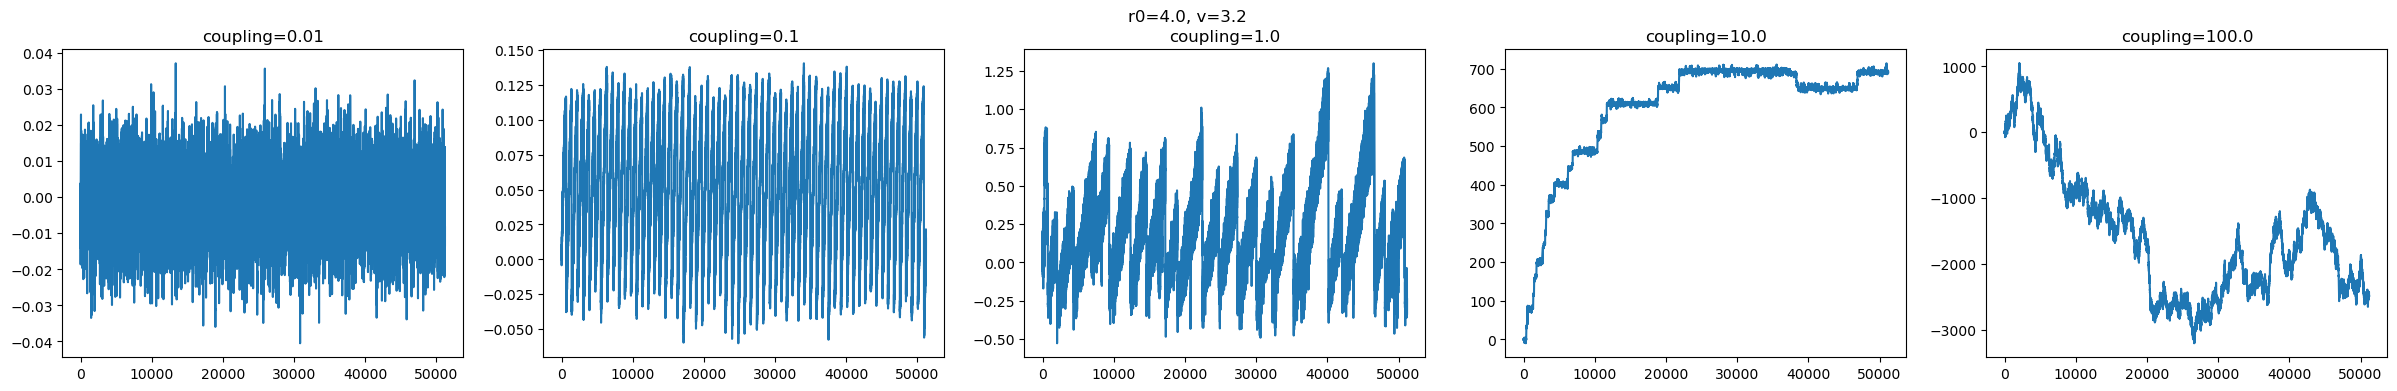

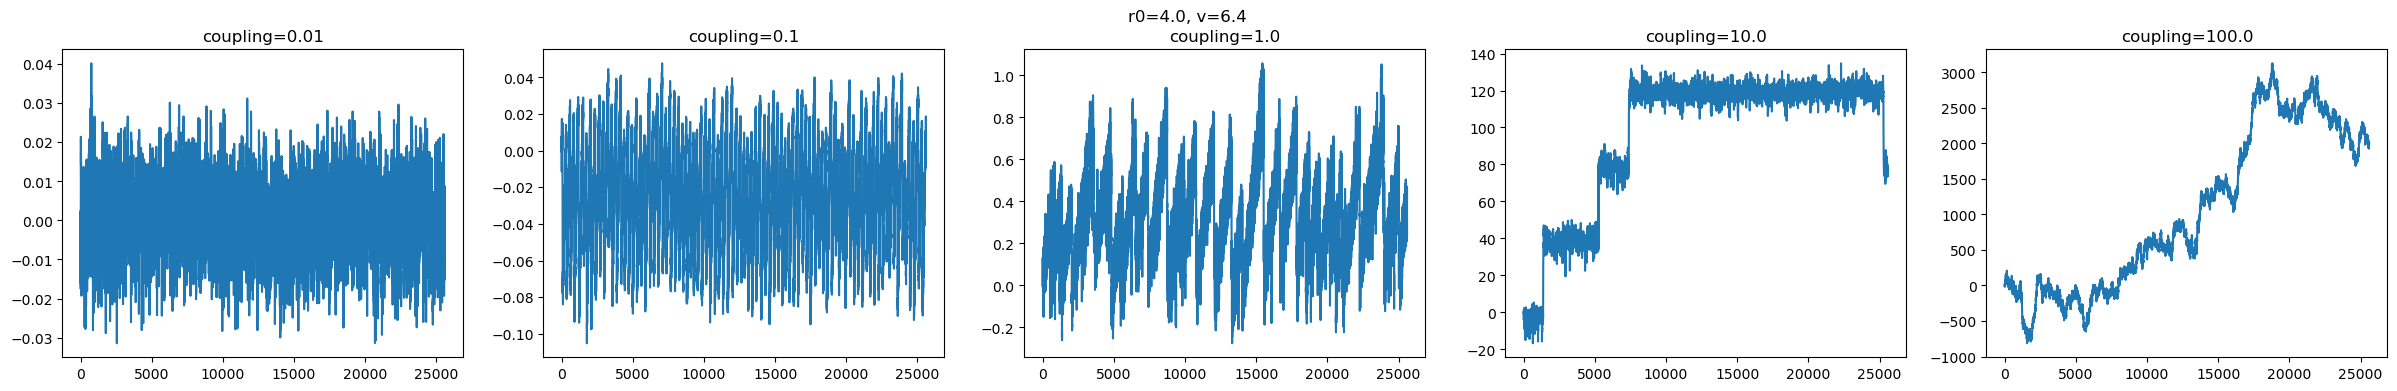

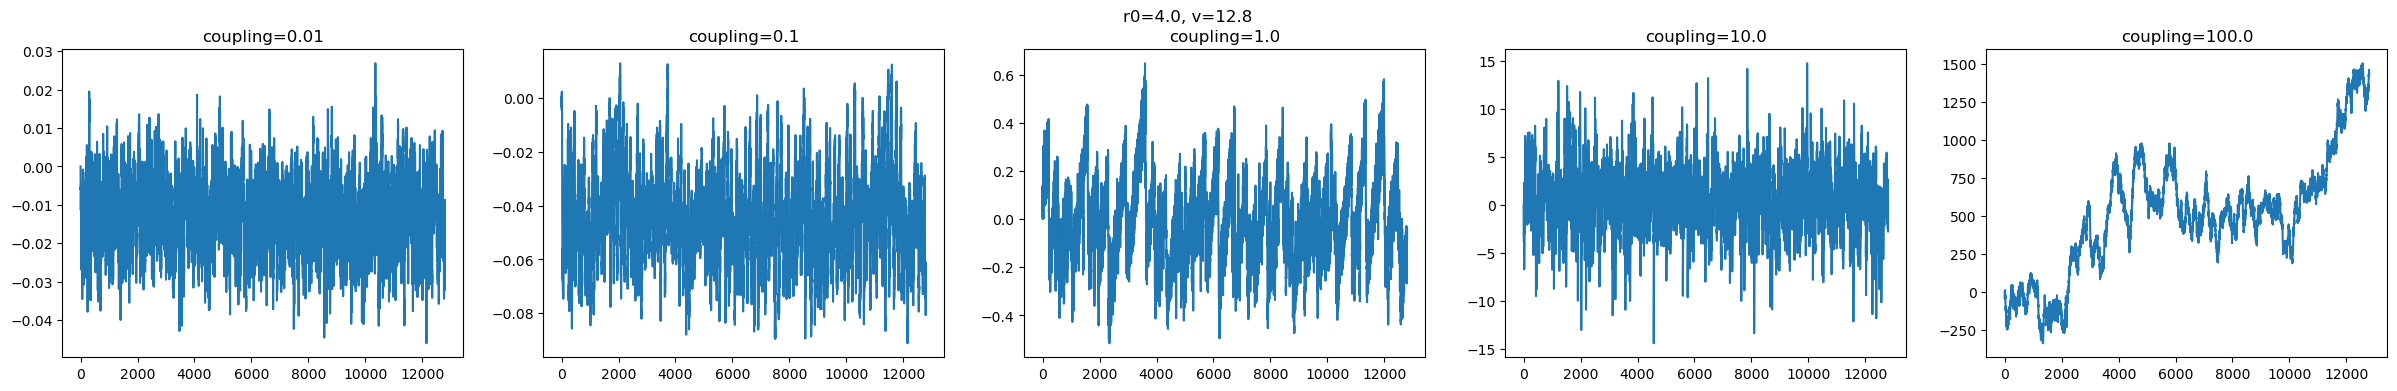

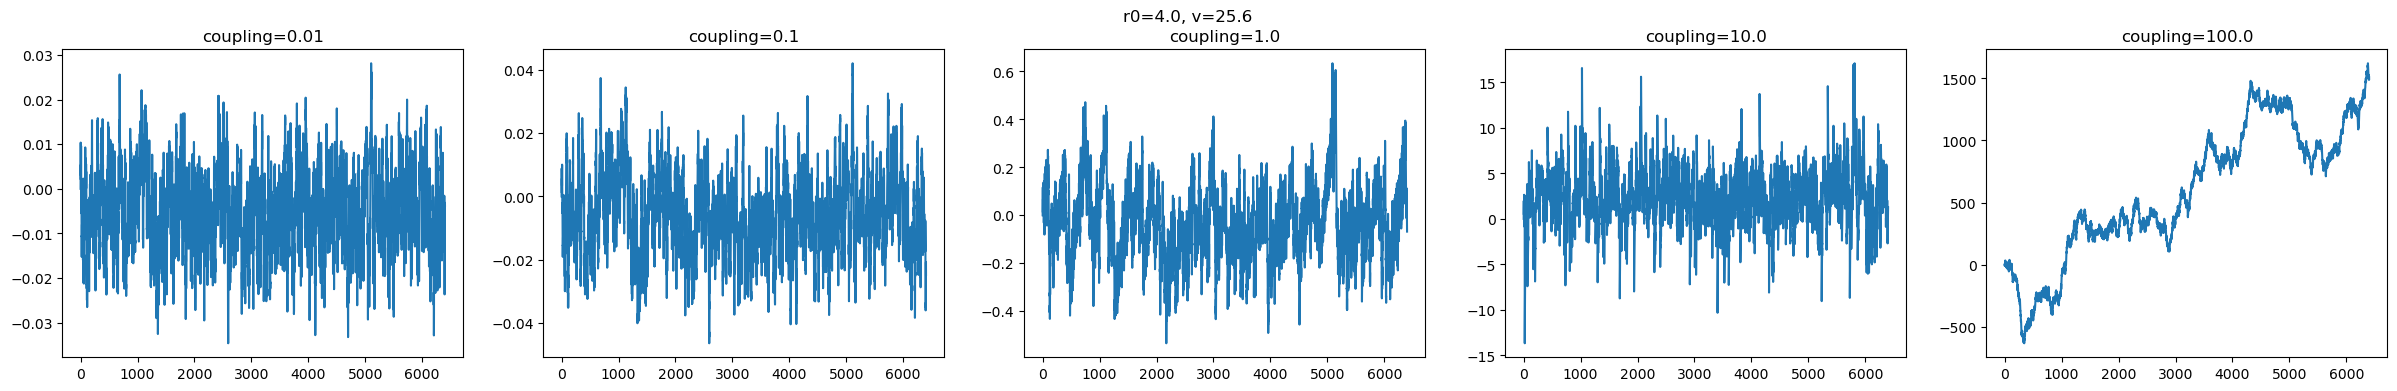

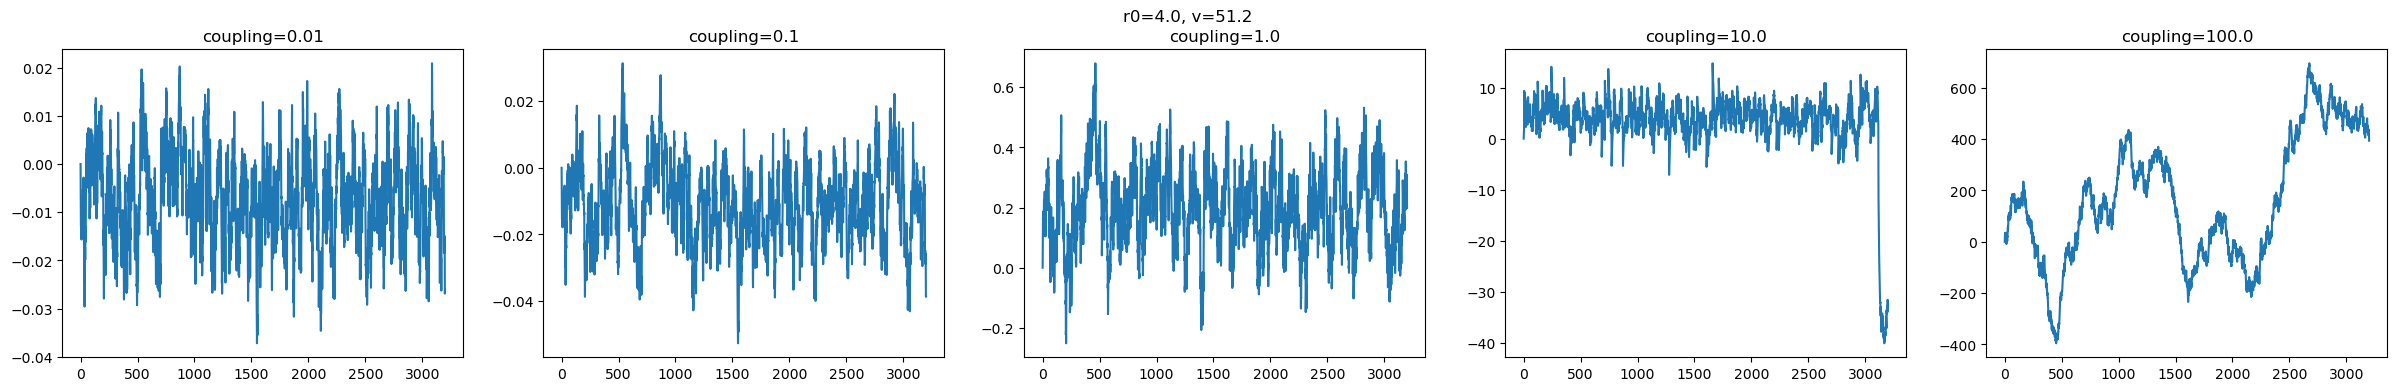

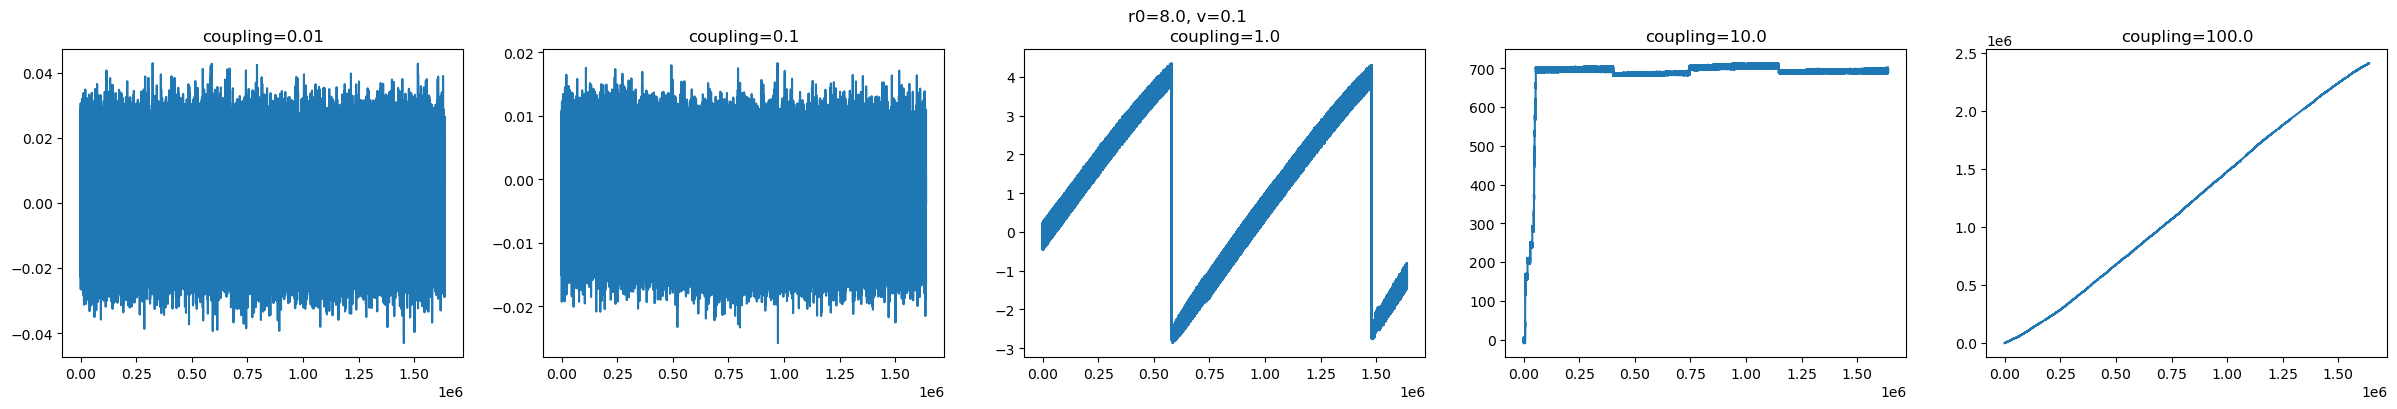

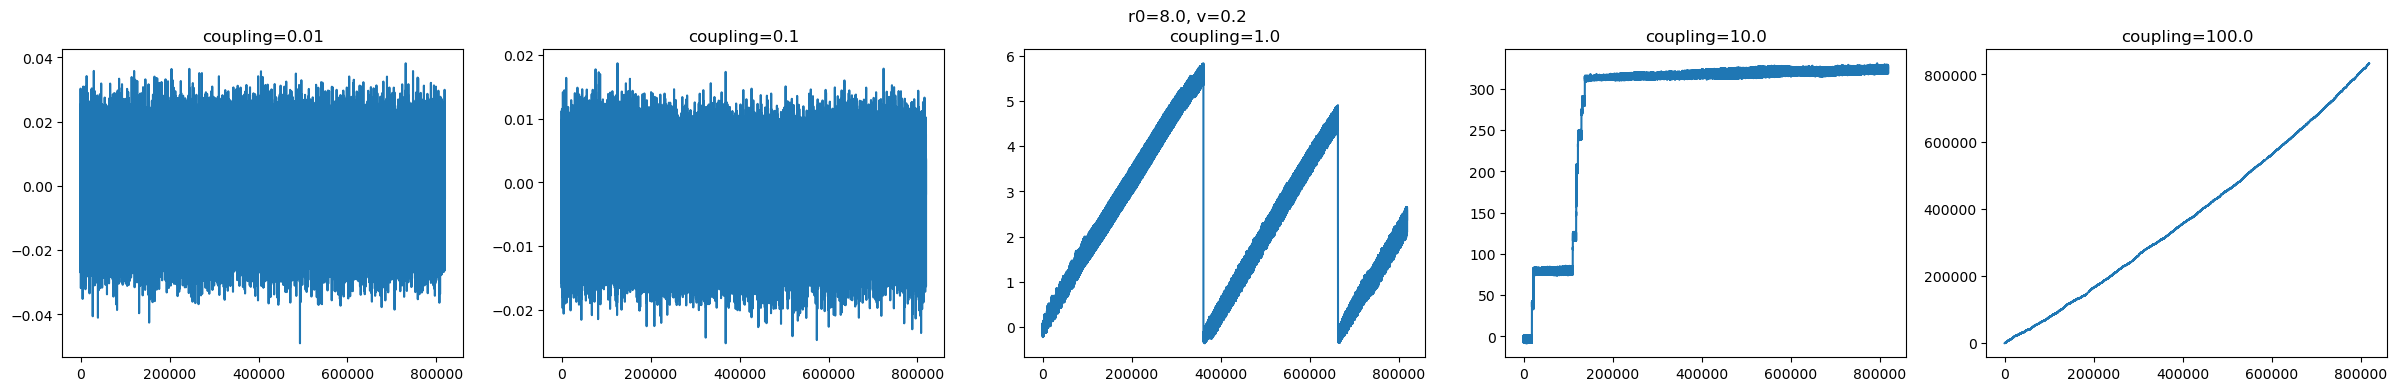

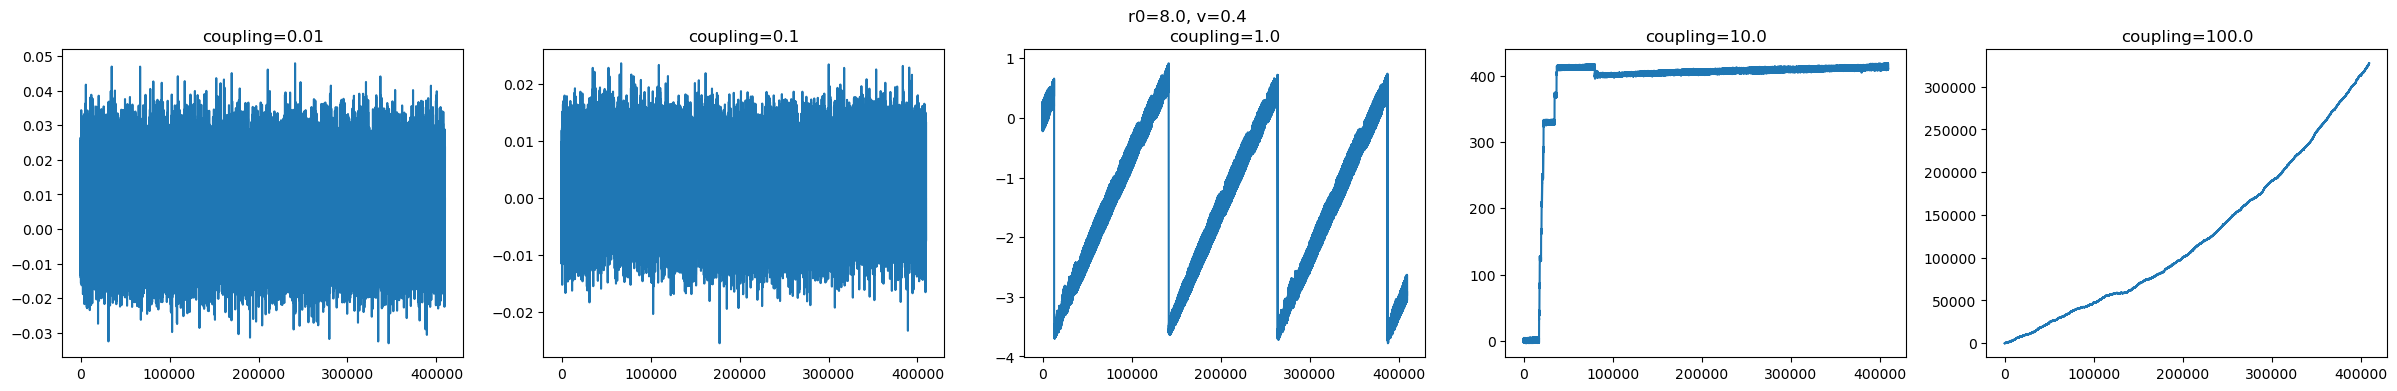

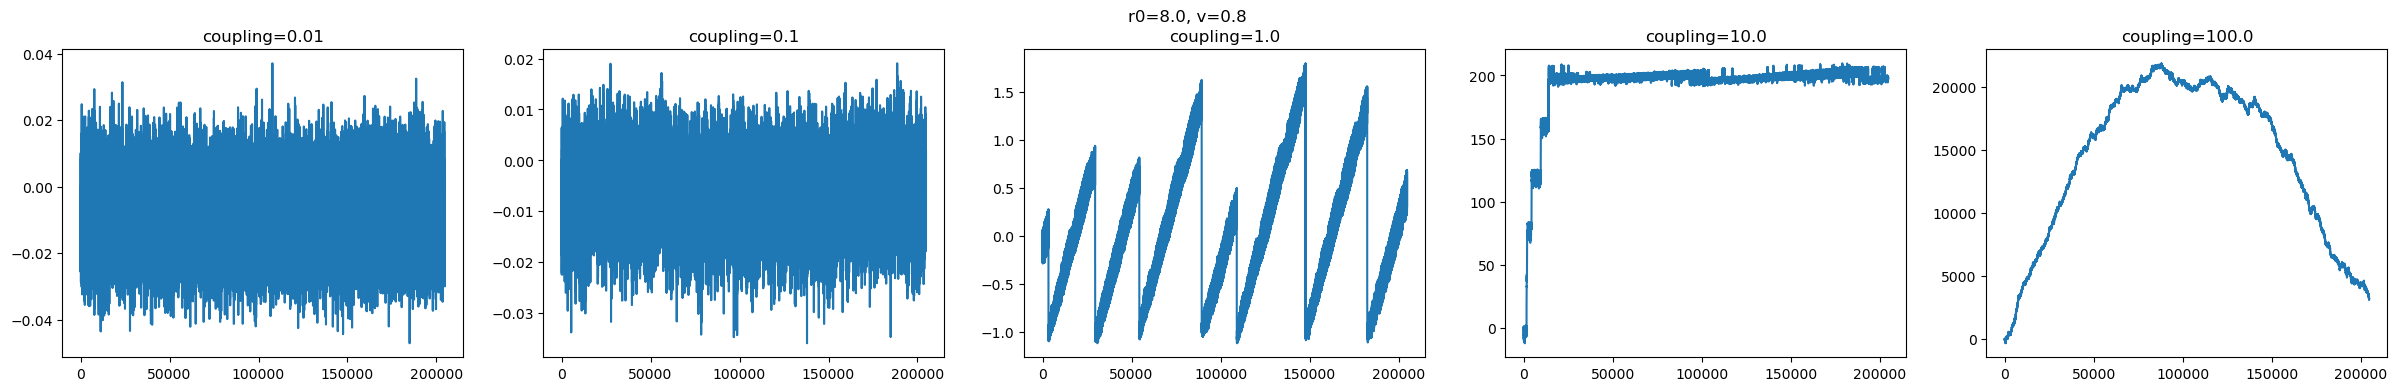

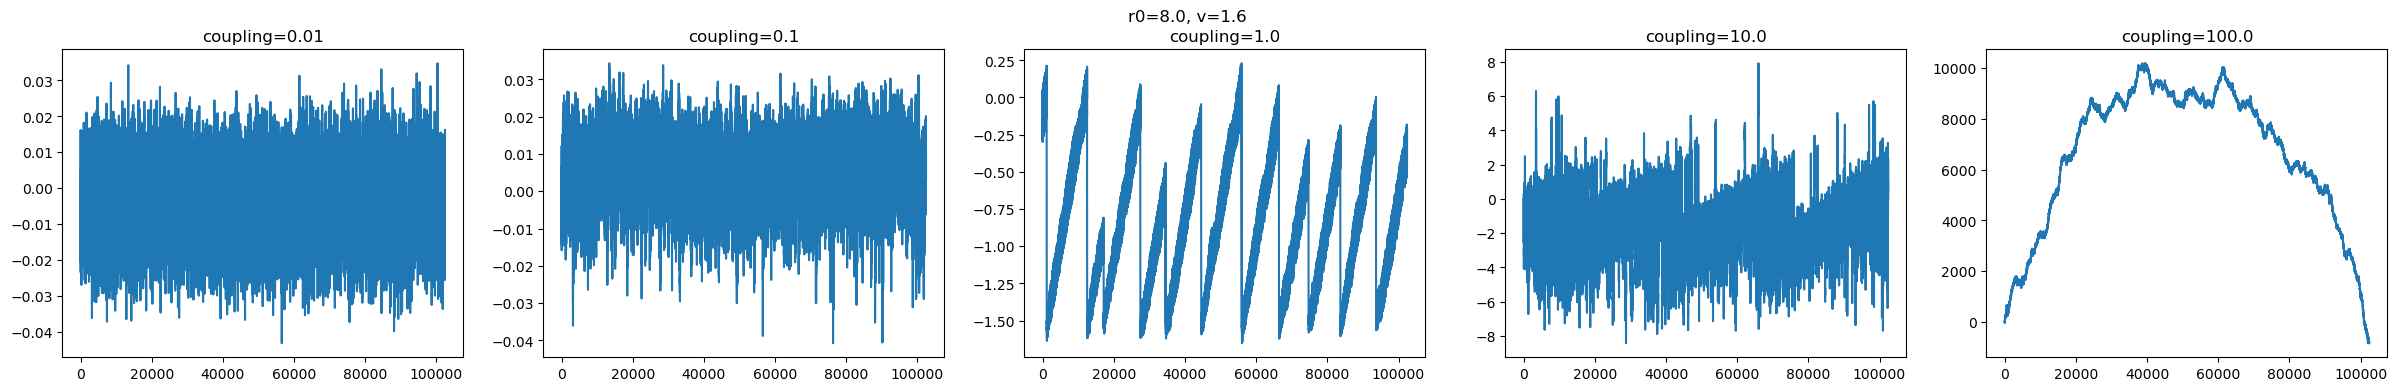

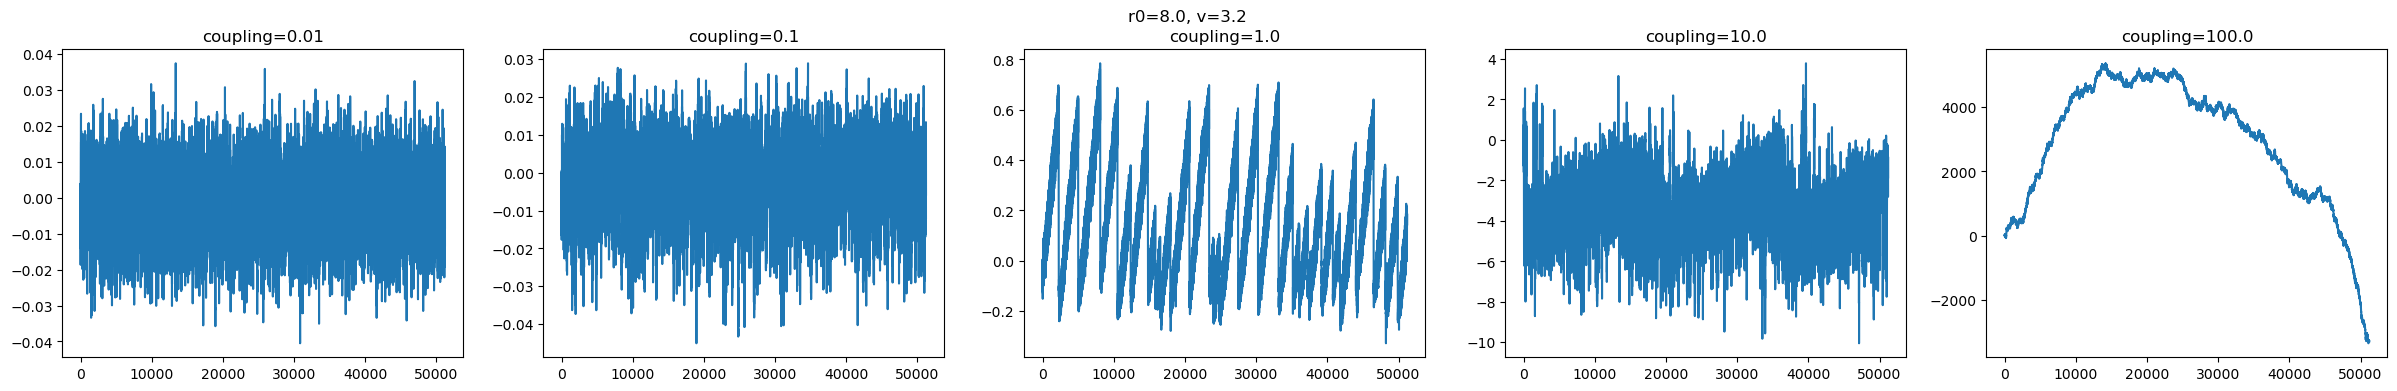

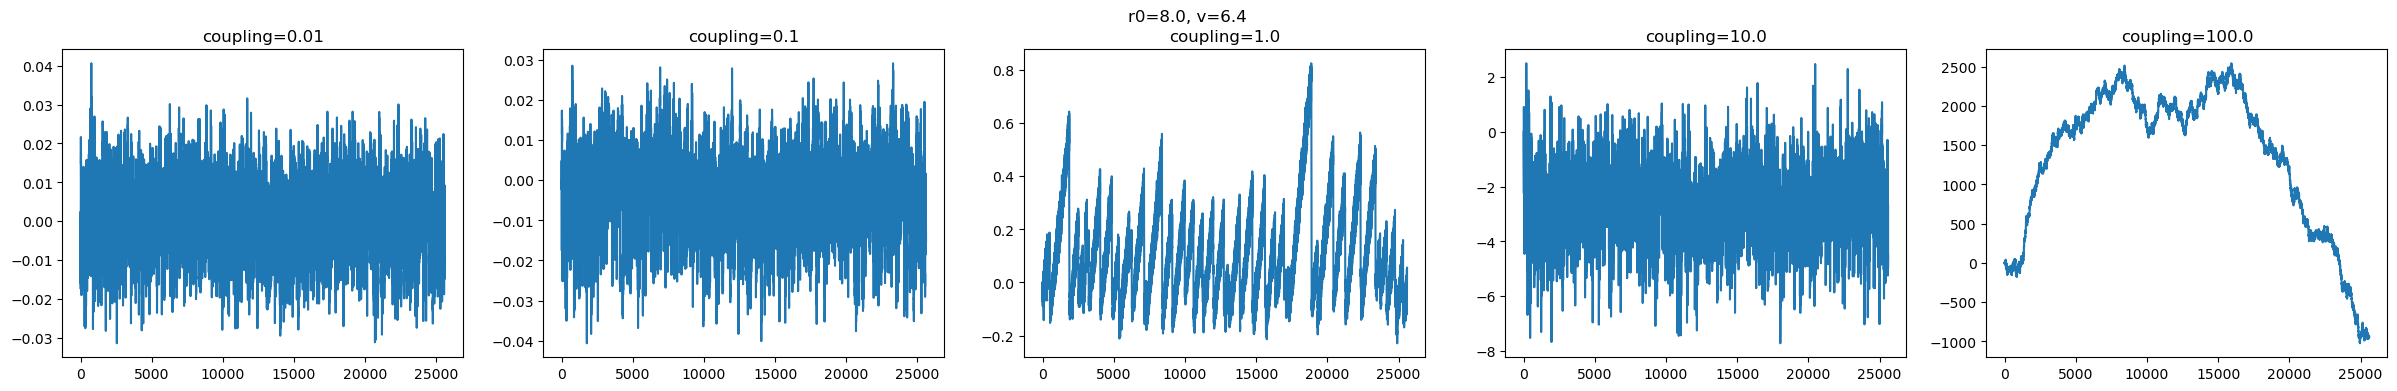

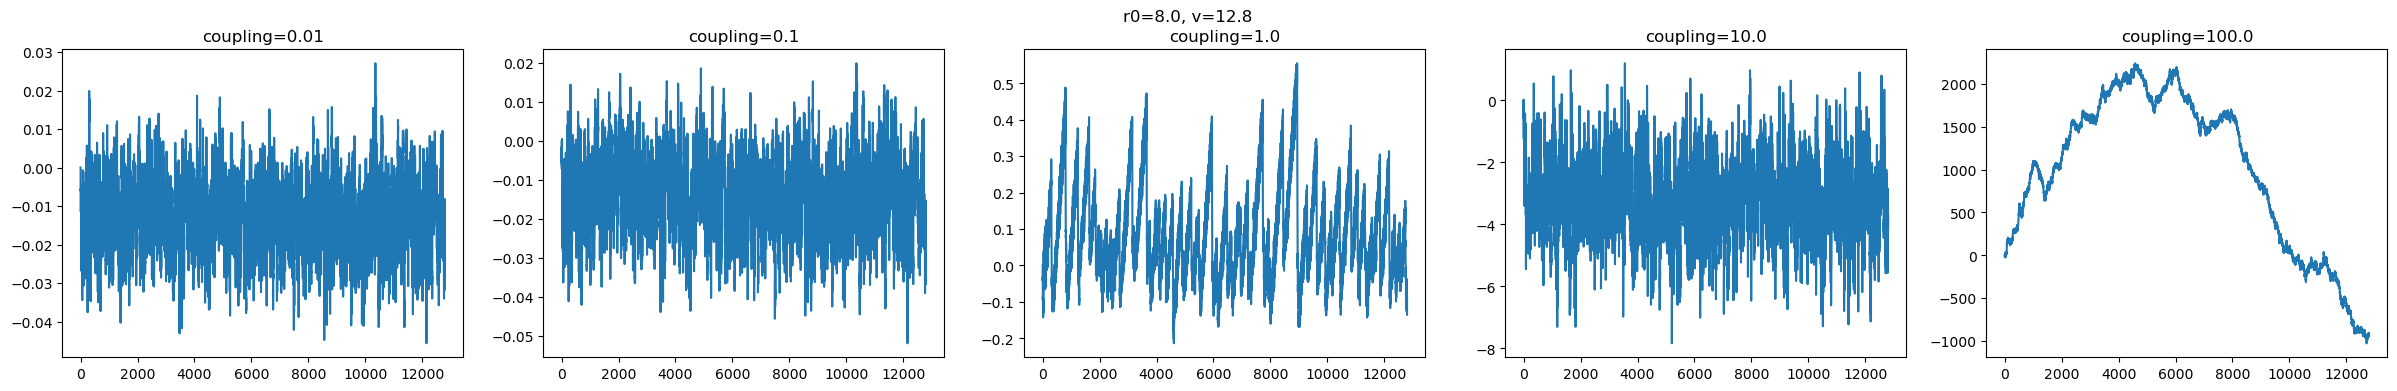

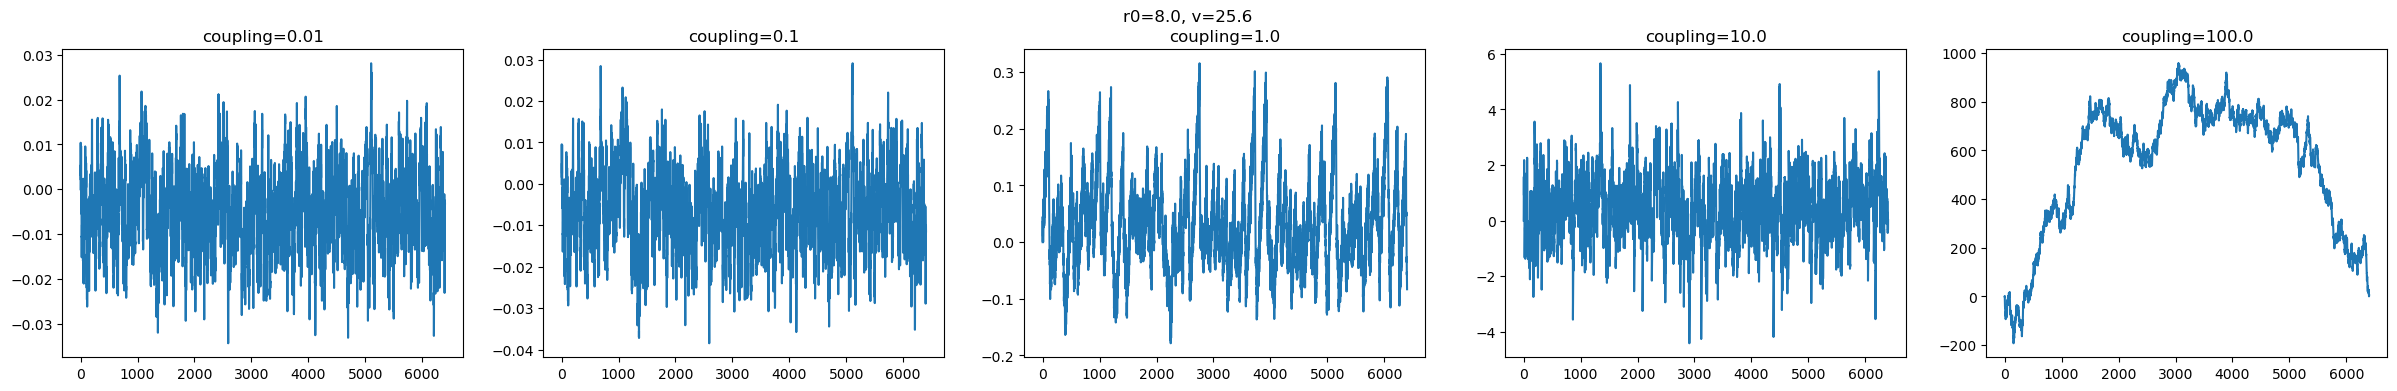

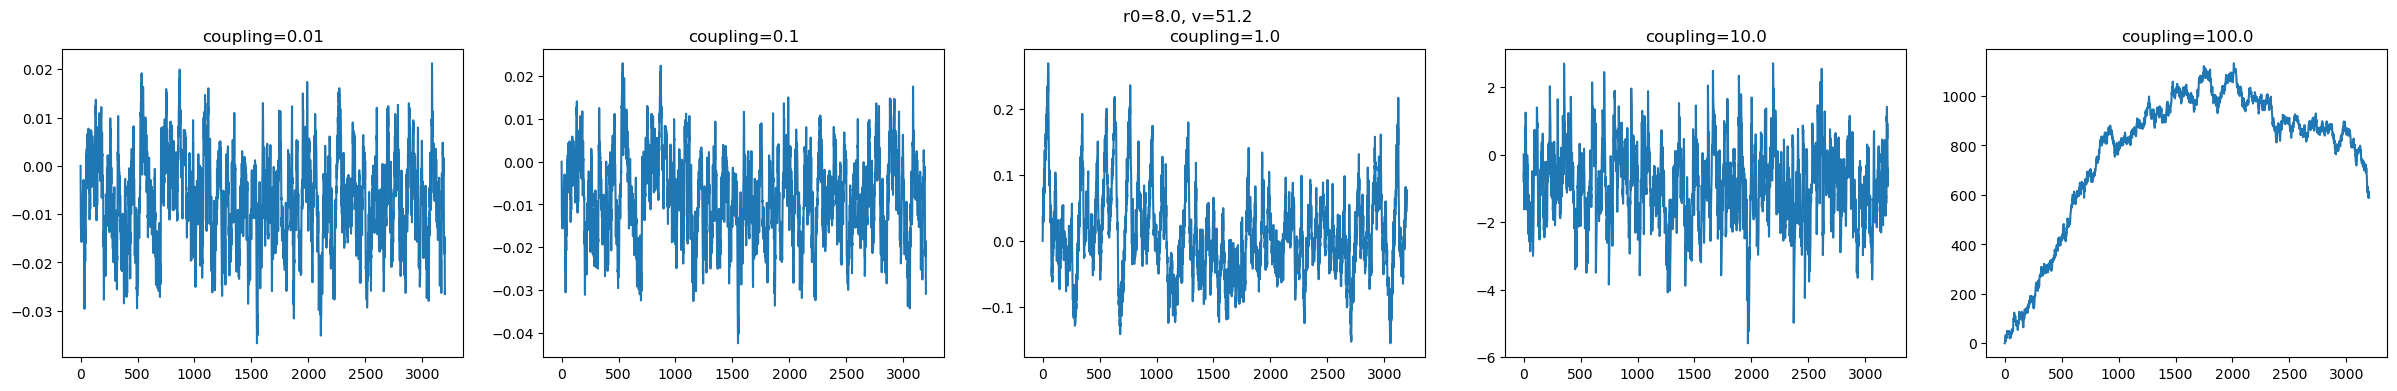

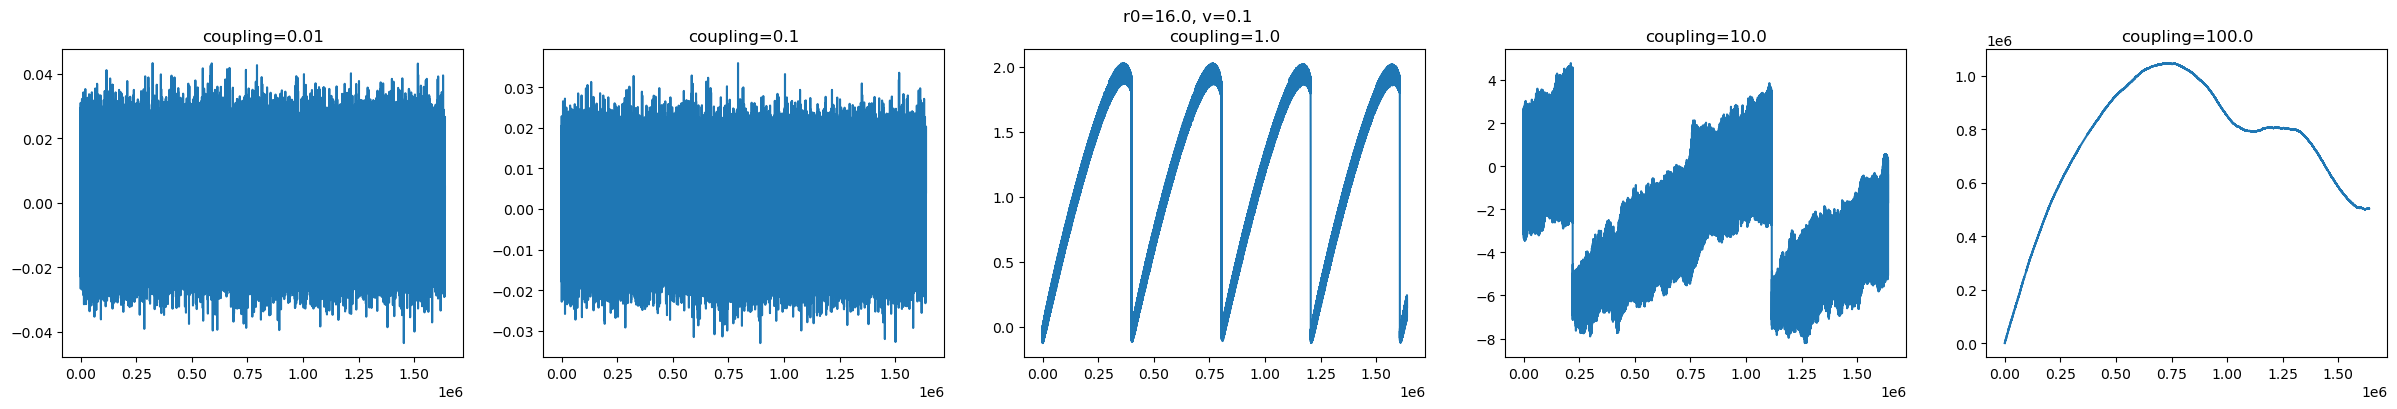

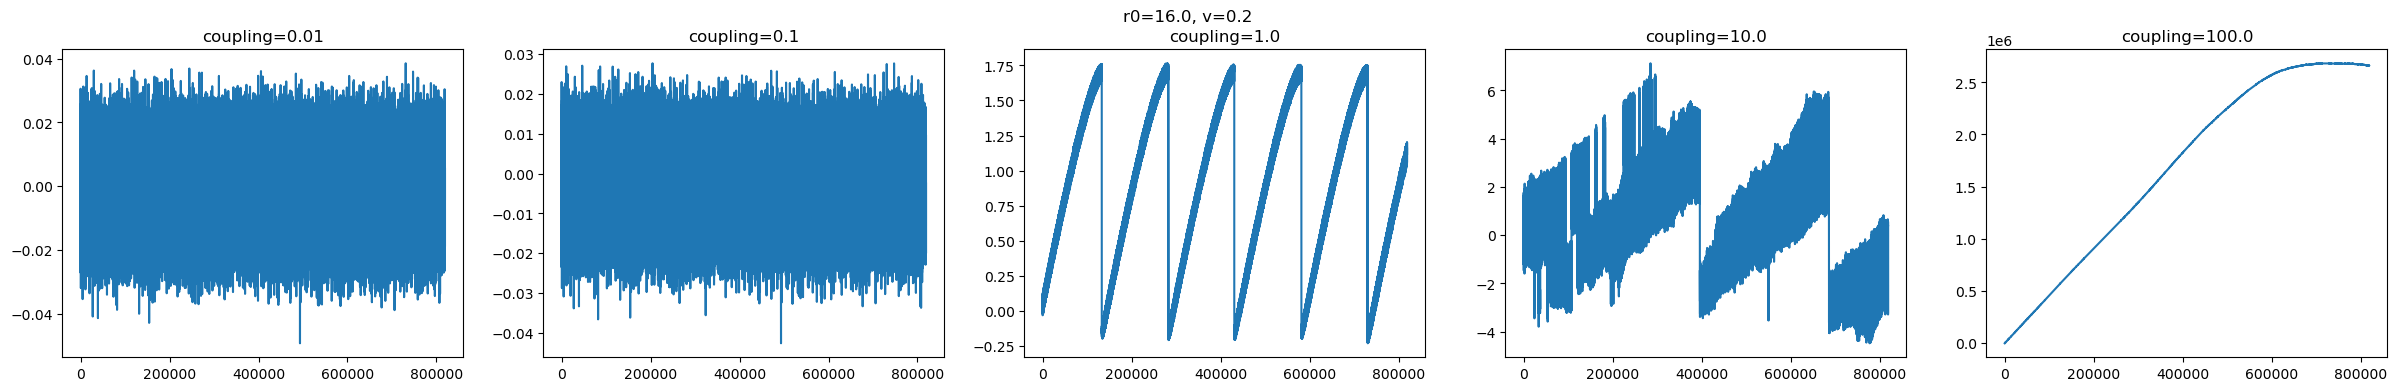

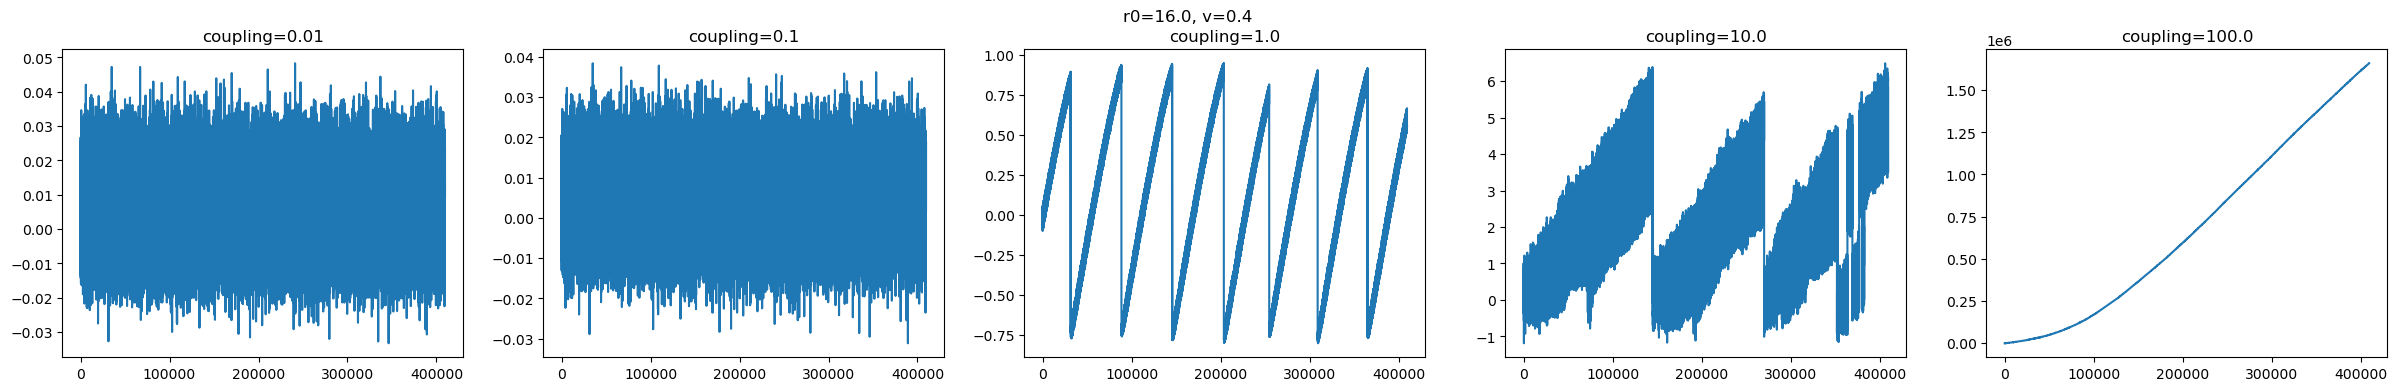

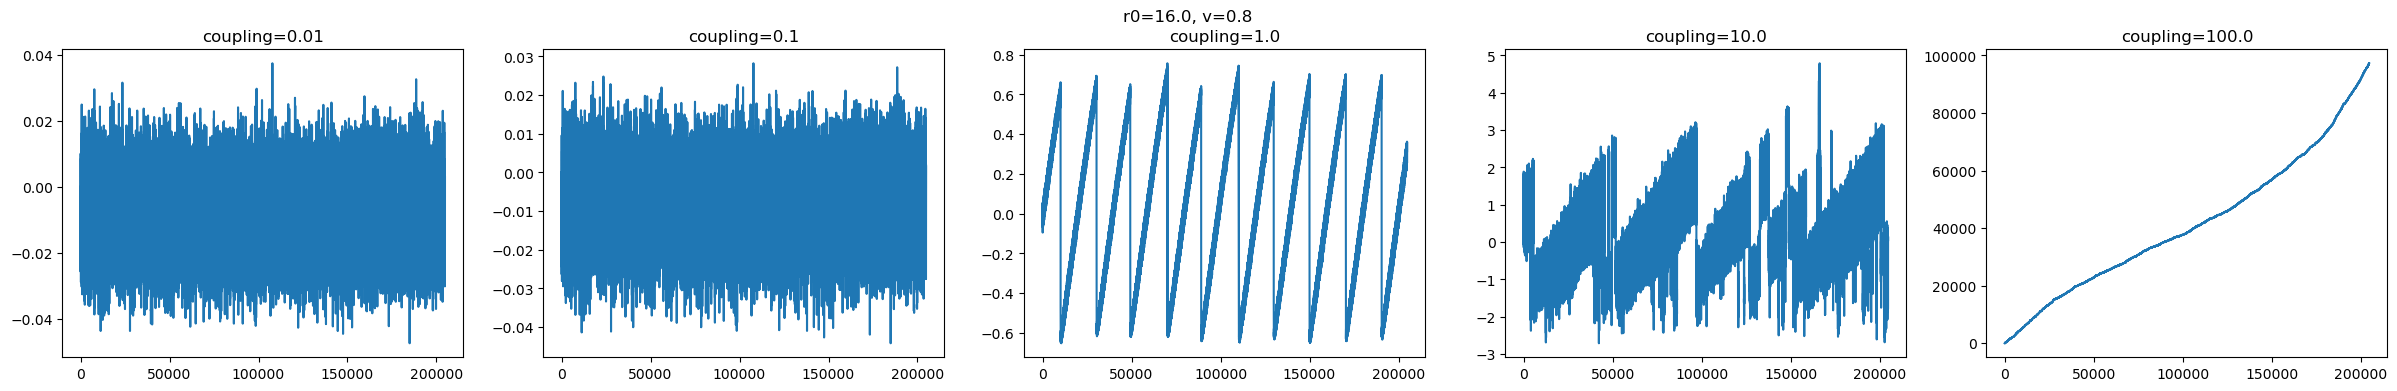

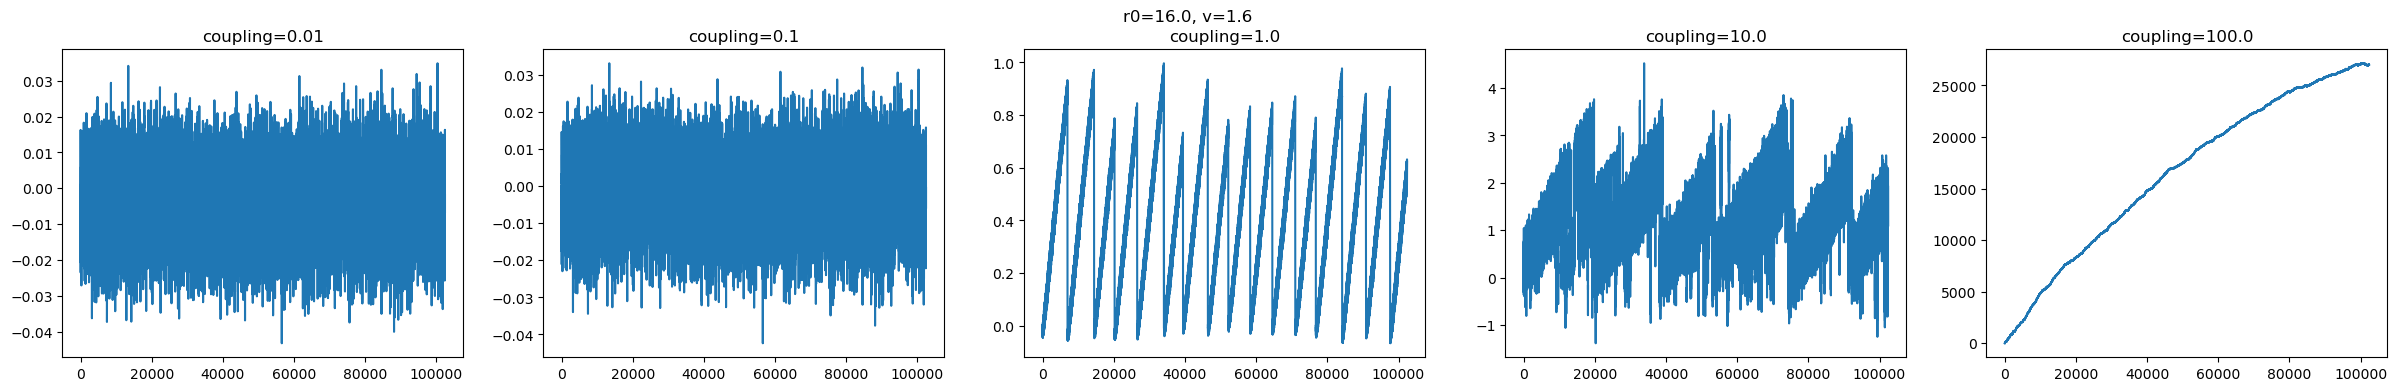

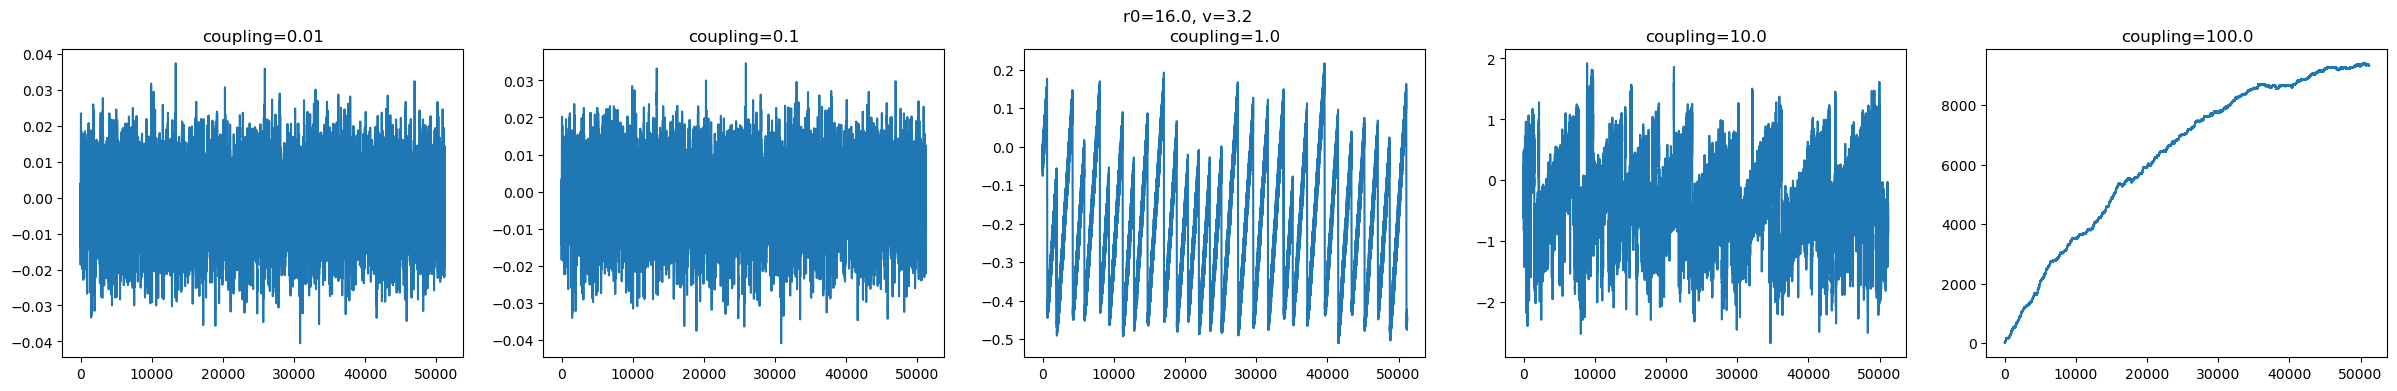

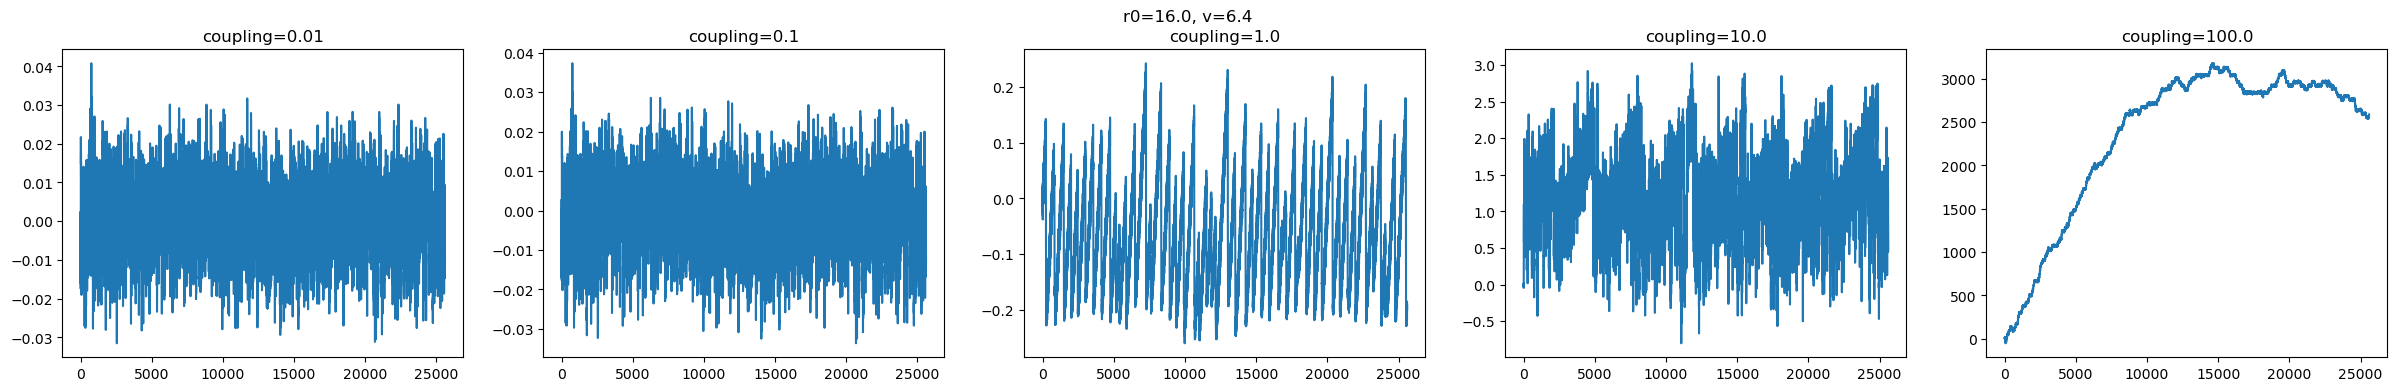

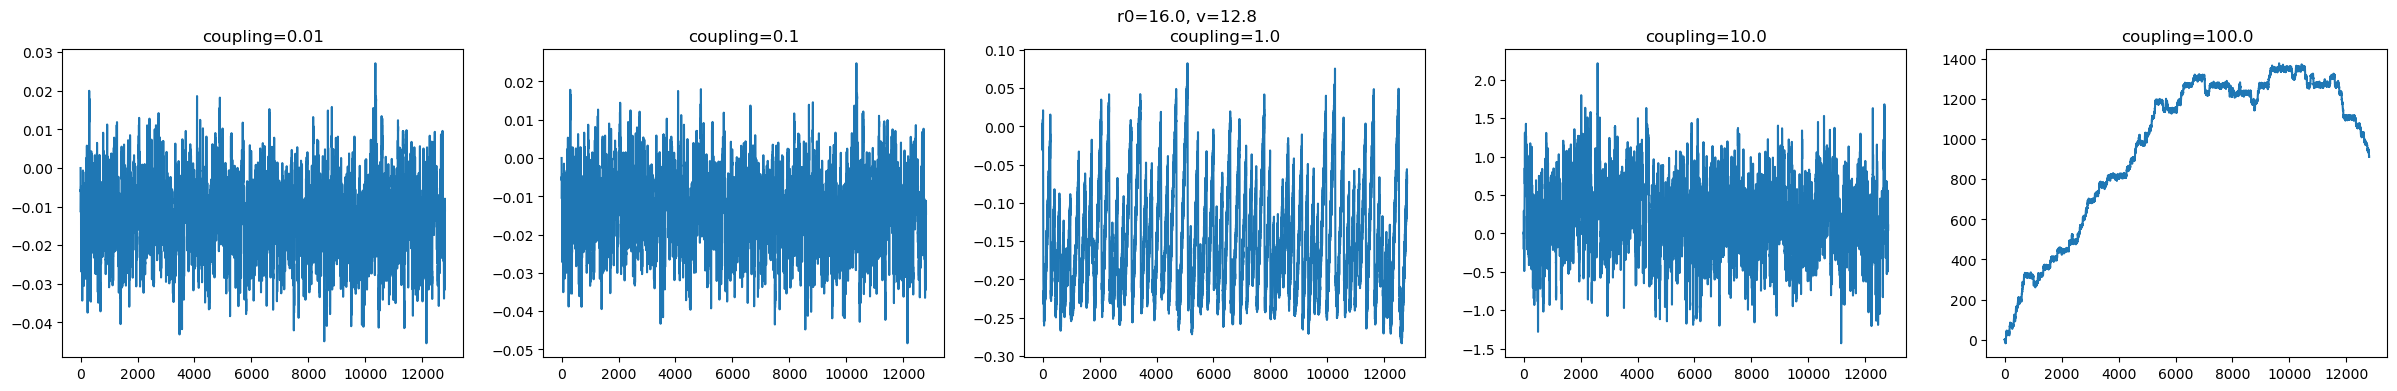

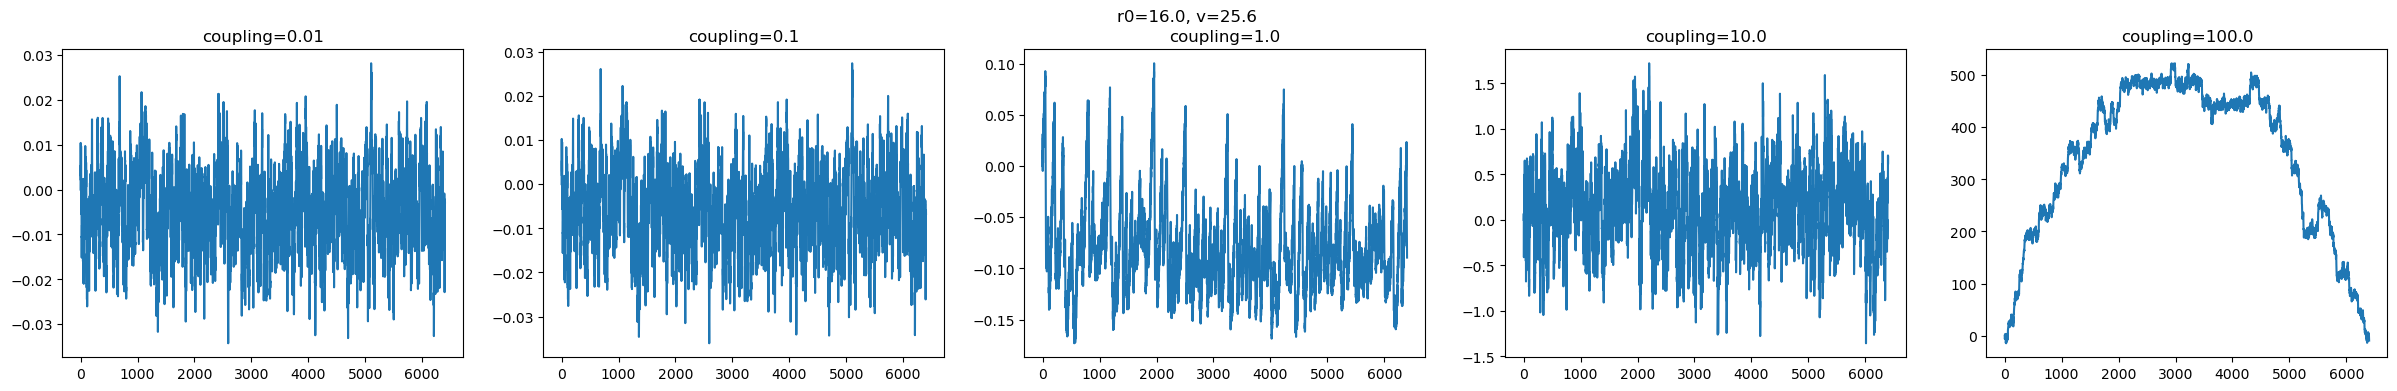

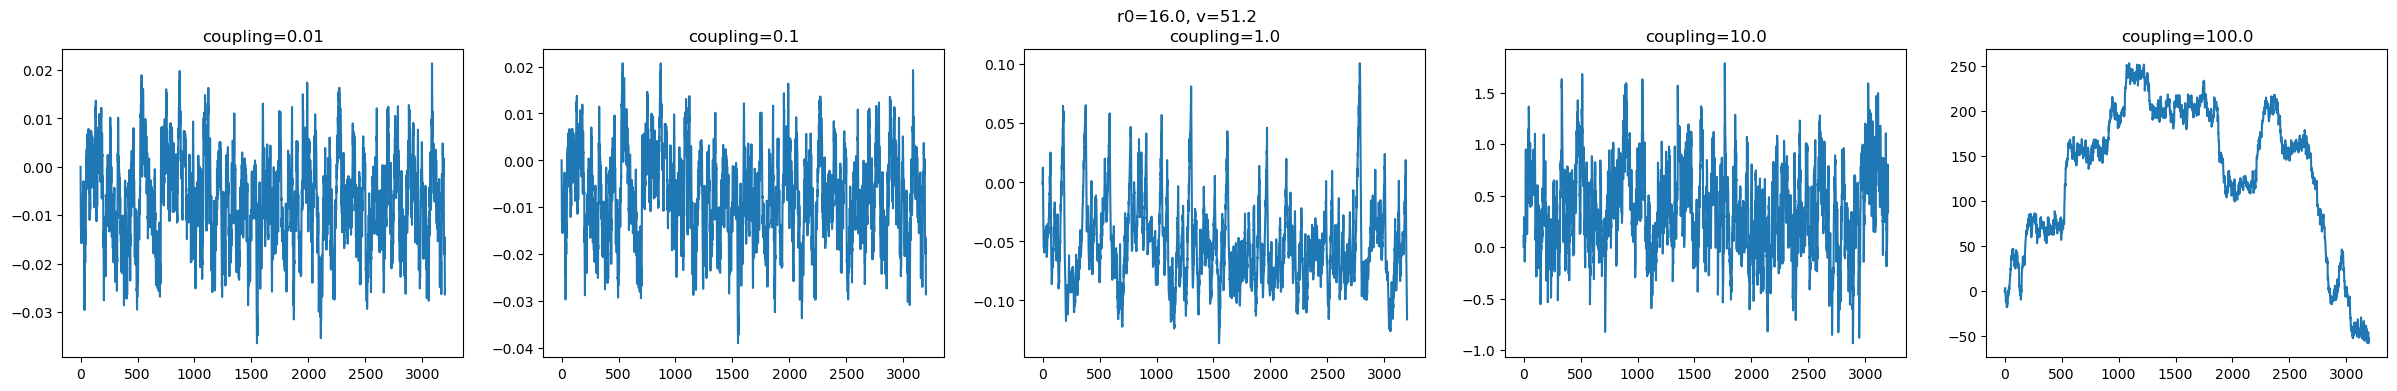

In [5]:
plot_traces = True
for r0, df_r0 in df.groupby("r0"):
    for v, df_v in df_r0.groupby("v"):
        num_plots = len(df_v)
        df_v = df_v.sort_values("coupling")
        fig, axes = plt.subplots(1, num_plots, figsize=(6*num_plots, 4), sharex=plot_traces)
        for i, (idx, row) in enumerate(df_v.iterrows()):
            tseries = row["centered_u_unwrapped_series"]
            tseries_cut = tseries[len(tseries)//10:len(tseries)//3 - len(tseries)//10] - tseries[len(tseries)//10]
            #min_val, max_val = np.quantile(tseries_cut, [0.01, 0.99])
            if(plot_traces):
                axes[i].plot(tseries_cut)
            else:
                axes[i].hist(tseries_cut, bins=100, density=True)
                axes[i].set_yscale("log")
            axes[i].set_title(f"coupling={row['coupling']}")
        fig.suptitle(f"r0={r0}, v={v}")
        plt.show()